# PPR Feature Engineering and EDA

This notebook builds a reproducible feature-engineering and pre-modelling analysis workflow for residential sale price prediction in Ireland using the cleaned Irish Property Price Register training data.

The focus here is **feature engineering, leakage control, and evidence-based feature selection**. This notebook does **not** train the final production model, except for lightweight validation models used to test whether feature blocks add value.

## Notebook Roadmap

The notebook is organised to answer three practical questions before final modelling:

1. Which engineered features add useful signal for predicting `log_price`?
2. Which features are risky because of leakage or poor future availability?
3. Which feature blocks should be kept, made optional, or dropped before the final modelling notebook?

The main datasets used are:

- `ppr-group-22312913-train-cleaned.csv`
- `ppr-group-22312913-test.csv`

In [28]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
TRAIN_PATH = PROJECT_ROOT / "ppr-group-22312913-train-cleaned.csv"
TEST_PATH = PROJECT_ROOT / "ppr-group-22312913-test.csv"

RANDOM_STATE = 42
VAL_MONTHS = 12
TARGET_CANDIDATES = [
    "Price (€)",
    "Price(EUR)",
    "Price",
    "price",
    "price_eur",
    "price_euro",
]

print("Train path:", TRAIN_PATH)
print("Test path :", TEST_PATH)

Train path: /Users/danilamacijauskas/Desktop/cs2025-2026/2-semester/Data_Analytics/project/ppr-group-22312913-train-cleaned.csv
Test path : /Users/danilamacijauskas/Desktop/cs2025-2026/2-semester/Data_Analytics/project/ppr-group-22312913-test.csv


## Helper Functions

To keep the notebook readable, the main wrangling and validation steps are wrapped in small helper functions. The helpers aim to be robust to small column-name differences and should warn rather than fail where possible.

In [29]:
def normalise_name(name):
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())


def find_column(df, candidates):
    lookup = {normalise_name(col): col for col in df.columns}

    for candidate in candidates:
        if candidate in df.columns:
            return candidate

        normalised = normalise_name(candidate)
        if normalised in lookup:
            return lookup[normalised]

    for col in df.columns:
        col_key = normalise_name(col)
        for candidate in candidates:
            cand_key = normalise_name(candidate)
            if cand_key in col_key or col_key in cand_key:
                return col

    return None


def detect_target_column(df):
    target_col = find_column(df, TARGET_CANDIDATES)
    if target_col is None:
        warnings.warn("Target column could not be detected automatically.")
    return target_col


def coerce_price_series(series):
    if series is None:
        return None
    cleaned = (
        series.astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("€", "", regex=False)
        .str.replace(r"[^0-9.\-]", "", regex=True)
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )
    return pd.to_numeric(cleaned, errors="coerce")


def yes_no_to_binary(series):
    if series is None:
        return None

    text = series.astype("string").str.strip().str.lower()
    result = pd.Series(np.nan, index=series.index, dtype="float64")
    result[text.isin({"yes", "y", "true", "1"})] = 1.0
    result[text.isin({"no", "n", "false", "0"})] = 0.0
    return result


def extract_routing_key(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().upper().replace(" ", "")
    if text in {"", "UNKNOWN", "NAN", "NONE"}:
        return pd.NA

    if text.startswith("D6W"):
        return "D6W"

    if re.match(r"^[A-Z]\d{2}", text):
        return text[:3]

    match = re.search(r"(D6W|[A-Z]\d{2})", text)
    if match:
        return match.group(1)

    return pd.NA


def clean_county_series(series):
    if series is None:
        return None

    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(r"^co\.?\s+", "", regex=True, case=False)
        .str.title()
    )
    cleaned = cleaned.replace({"": pd.NA, "Nan": pd.NA, "None": pd.NA})
    return cleaned


def add_address_features(df, address_col="address_text"):
    df = df.copy()

    if address_col not in df.columns:
        for col in [
            "is_apartment_text",
            "has_estate_term",
            "has_rural_term",
            "has_house_number",
            "address_token_count",
        ]:
            df[col] = np.nan
        warnings.warn(f"Address column '{address_col}' not found; address features were left empty.")
        return df

    address_text = df[address_col].astype("string").fillna("").str.lower()

    df["is_apartment_text"] = address_text.str.contains(
        r"\b(apt|apartment|flat|unit|suite|duplex|penthouse)\b",
        regex=True,
    ).astype("int8")
    df["has_estate_term"] = address_text.str.contains(
        r"\b(estate|manor|park|court|view|close|gardens?|grange|woods?|heights?|green|lawns?|crescent|villas?)\b",
        regex=True,
    ).astype("int8")
    df["has_rural_term"] = address_text.str.contains(
        r"\b(road|rd|lane|ln|cross|upper|lower|townland|farm|west|east|north|south|bally|kil|mount)\b",
        regex=True,
    ).astype("int8")
    df["has_house_number"] = address_text.str.contains(
        r"(^|\s)(no\.?\s*)?\d+[a-z]?(\s|,|$)",
        regex=True,
    ).astype("int8")
    df["address_token_count"] = address_text.str.split().str.len().fillna(0).astype("int16")

    return df


def prepare_base_dataframe(df, dataset_label):
    work = df.copy()

    sale_month_col = find_column(
        work,
        ["Year-Month of Sale (yyyy-mm)", "Year-Month of Sale", "Sale Month", "year_month"],
    )
    sale_date_col = find_column(
        work,
        ["Date of Sale (dd/mm/yyyy)", "Date of Sale", "Sale Date"],
    )
    address_col = find_column(work, ["Address_clean", "Address"])
    county_col = find_column(work, ["County"])
    area_code_col = find_column(work, ["Area Code", "AreaCode", "Routing Key"])
    eircode_col = find_column(work, ["Eircode", "EIRCODE"])
    not_full_market_col = find_column(work, ["Not Full Market Price"])
    vat_exclusive_col = find_column(work, ["VAT Exclusive"])
    is_second_hand_col = find_column(work, ["Is_Second_Hand", "Is Second Hand"])
    description_col = find_column(work, ["Description of Property"])
    target_col = detect_target_column(work)

    if sale_month_col is not None:
        work["sale_date"] = pd.to_datetime(work[sale_month_col], format="%Y-%m", errors="coerce")
    elif sale_date_col is not None:
        work["sale_date"] = pd.to_datetime(work[sale_date_col], dayfirst=True, errors="coerce")
    else:
        work["sale_date"] = pd.NaT
        warnings.warn(f"{dataset_label}: no sale date column was detected.")

    work["sale_period"] = work["sale_date"].dt.to_period("M")
    work["sale_month_start"] = work["sale_period"].dt.to_timestamp()

    if address_col is not None:
        work["address_text"] = work[address_col].astype("string")
    else:
        work["address_text"] = pd.Series(pd.NA, index=work.index, dtype="string")
        warnings.warn(f"{dataset_label}: no address column was detected.")

    if county_col is not None:
        work["county_clean"] = clean_county_series(work[county_col])
    else:
        work["county_clean"] = pd.Series(pd.NA, index=work.index, dtype="string")
        warnings.warn(f"{dataset_label}: no county column was detected.")

    if area_code_col is not None:
        work["area_code_clean"] = work[area_code_col].map(extract_routing_key)
    elif eircode_col is not None:
        work["area_code_clean"] = work[eircode_col].map(extract_routing_key)
    else:
        work["area_code_clean"] = pd.Series(pd.NA, index=work.index, dtype="string")

    work["area_code_missing"] = work["area_code_clean"].isna().astype("int8")
    work["area_code_clean"] = work["area_code_clean"].fillna("Unknown")

    if target_col is not None:
        work["price_numeric"] = coerce_price_series(work[target_col])
    else:
        work["price_numeric"] = np.nan

    work["not_full_market_bin"] = (
        yes_no_to_binary(work[not_full_market_col]) if not_full_market_col is not None else np.nan
    )
    work["vat_exclusive_bin"] = (
        yes_no_to_binary(work[vat_exclusive_col]) if vat_exclusive_col is not None else np.nan
    )

    if is_second_hand_col is not None:
        work["is_second_hand_bin"] = yes_no_to_binary(work[is_second_hand_col])
    elif description_col is not None:
        desc = work[description_col].astype("string").str.lower()
        work["is_second_hand_bin"] = np.where(
            desc.str.contains("second-hand", na=False),
            1.0,
            np.where(desc.str.contains("new dwelling", na=False), 0.0, np.nan),
        )
    else:
        work["is_second_hand_bin"] = np.nan

    work["dataset_label"] = dataset_label

    column_map = {
        "sale_month_col": sale_month_col,
        "sale_date_col": sale_date_col,
        "address_col": address_col,
        "county_col": county_col,
        "area_code_col": area_code_col,
        "eircode_col": eircode_col,
        "not_full_market_col": not_full_market_col,
        "vat_exclusive_col": vat_exclusive_col,
        "is_second_hand_col": is_second_hand_col,
        "description_col": description_col,
        "target_col": target_col,
    }

    return work, column_map


def add_time_features(df, origin_period):
    df = df.copy()
    df["sale_year"] = df["sale_date"].dt.year
    df["sale_month"] = df["sale_date"].dt.month
    df["sale_quarter"] = df["sale_date"].dt.quarter
    df["month_index"] = (
        (df["sale_year"] - origin_period.year) * 12
        + (df["sale_month"] - origin_period.month)
    )

    month_angle = 2 * np.pi * (df["sale_month"] - 1) / 12
    df["sin_month"] = np.sin(month_angle)
    df["cos_month"] = np.cos(month_angle)
    return df

In [30]:
def complete_group_month_grid(monthly_df, group_col, period_col="sale_period", end_period=None):
    if monthly_df.empty:
        return monthly_df.copy()

    start_period = monthly_df[period_col].min()
    final_period = end_period if end_period is not None else monthly_df[period_col].max()
    full_periods = pd.period_range(start_period, final_period, freq="M")

    frames = []
    for group_value, group_df in monthly_df.groupby(group_col):
        expanded = group_df.set_index(period_col).reindex(full_periods)
        expanded[group_col] = group_value
        expanded.index.name = period_col
        frames.append(expanded.reset_index())

    return pd.concat(frames, ignore_index=True)


def add_activity_features(base_df, reference_df, group_col, prefix, end_period=None, allow_unknown=False):
    base_df = base_df.copy()
    current_name = f"sales_count_{prefix}_month"
    rolling_name = f"rolling_12m_sales_{prefix}"

    required = {group_col, "sale_period"}
    if not required.issubset(reference_df.columns):
        base_df[current_name] = np.nan
        base_df[rolling_name] = np.nan
        warnings.warn(f"Activity features for {prefix} could not be created because the required columns are missing.")
        return base_df, pd.DataFrame()

    ref = reference_df.copy()
    ref = ref[ref[group_col].notna() & ref["sale_period"].notna()]
    if not allow_unknown:
        ref = ref[ref[group_col] != "Unknown"]

    monthly = (
        ref.groupby([group_col, "sale_period"])
        .size()
        .rename("monthly_sales_count")
        .reset_index()
    )

    if monthly.empty:
        base_df[current_name] = np.nan
        base_df[rolling_name] = np.nan
        warnings.warn(f"No monthly activity table was available for {prefix}.")
        return base_df, monthly

    expanded = complete_group_month_grid(monthly, group_col=group_col, end_period=end_period)
    expanded["monthly_sales_count"] = expanded["monthly_sales_count"].fillna(0)
    expanded[rolling_name] = expanded.groupby(group_col)["monthly_sales_count"].transform(
        lambda s: s.shift(1).rolling(12, min_periods=1).sum()
    )

    current_counts = monthly.rename(columns={"monthly_sales_count": current_name})

    base_df = base_df.merge(
        current_counts[[group_col, "sale_period", current_name]],
        on=[group_col, "sale_period"],
        how="left",
    )
    base_df = base_df.merge(
        expanded[[group_col, "sale_period", rolling_name]],
        on=[group_col, "sale_period"],
        how="left",
    )

    if group_col == "area_code_clean" and "area_code_missing" in base_df.columns:
        base_df.loc[base_df["area_code_missing"] == 1, [current_name, rolling_name]] = np.nan

    return base_df, expanded


def add_trailing_price_features(
    base_df,
    reference_df,
    group_col,
    prefix,
    end_period=None,
    windows=(6, 12),
):
    base_df = base_df.copy()
    required = {group_col, "sale_period", "log_price"}

    feature_names = [f"{prefix}_trailing_{window}m_median_log_price" for window in windows]

    if not required.issubset(reference_df.columns):
        for feature_name in feature_names:
            base_df[feature_name] = np.nan
        warnings.warn(f"Trailing price features for {prefix} could not be created because required columns are missing.")
        return base_df, pd.DataFrame()

    ref = reference_df.copy()
    ref = ref[ref[group_col].notna() & ref["sale_period"].notna() & ref["log_price"].notna()]
    if group_col == "area_code_clean":
        ref = ref[ref[group_col] != "Unknown"]

    monthly = (
        ref.groupby([group_col, "sale_period"])["log_price"]
        .median()
        .rename("monthly_group_median_log_price")
        .reset_index()
    )

    if monthly.empty:
        for feature_name in feature_names:
            base_df[feature_name] = np.nan
        warnings.warn(f"No monthly price history table was available for {prefix}.")
        return base_df, monthly

    expanded = complete_group_month_grid(monthly, group_col=group_col, end_period=end_period)

    min_history = {6: 3, 12: 6}
    for window in windows:
        feature_name = f"{prefix}_trailing_{window}m_median_log_price"
        expanded[feature_name] = expanded.groupby(group_col)["monthly_group_median_log_price"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=min_history.get(window, 1)).median()
        )

    merge_cols = [group_col, "sale_period"] + feature_names
    base_df = base_df.merge(expanded[merge_cols], on=[group_col, "sale_period"], how="left")

    if group_col == "area_code_clean" and "area_code_missing" in base_df.columns:
        base_df.loc[base_df["area_code_missing"] == 1, feature_names] = np.nan

    return base_df, expanded


def plot_binned_relationship(df, feature, target="log_price", bins=8, title=None):
    subset = df[[feature, target]].dropna().copy()
    if subset.empty or subset[feature].nunique() < 4:
        print(f"Not enough variation to bin '{feature}'.")
        return

    q = min(bins, subset[feature].nunique())
    subset["feature_bin"] = pd.qcut(subset[feature], q=q, duplicates="drop")
    summary = (
        subset.groupby("feature_bin", observed=False)[target]
        .agg(["median", "count"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=summary, x="feature_bin", y="median", color="#4C78A8", ax=ax)
    ax.set_title(title or f"Median log price by binned {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Median log price")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    display(summary)


def make_time_based_split(df, period_col="sale_period", val_months=12):
    periods = pd.PeriodIndex(df[period_col].dropna().unique(), freq="M").sort_values()
    if len(periods) <= val_months:
        raise ValueError("Not enough monthly periods for a time-based validation split.")

    val_periods = periods[-val_months:]
    train_mask = df[period_col].isin(periods[:-val_months])
    val_mask = df[period_col].isin(val_periods)
    return train_mask, val_mask, val_periods


def evaluate_ridge_stage(df, stage_name, numeric_features, categorical_features, target="log_price", val_months=12):
    numeric_features = [col for col in numeric_features if col in df.columns]
    categorical_features = [col for col in categorical_features if col in df.columns]
    feature_cols = numeric_features + categorical_features

    if not feature_cols:
        raise ValueError(f"{stage_name}: no usable features were found.")

    model_df = df[feature_cols + [target, "sale_period"]].copy()
    model_df = model_df[model_df[target].notna() & model_df["sale_period"].notna()]

    train_mask, val_mask, val_periods = make_time_based_split(model_df, val_months=val_months)

    X_train = model_df.loc[train_mask, feature_cols]
    X_val = model_df.loc[val_mask, feature_cols]
    y_train = model_df.loc[train_mask, target]
    y_val = model_df.loc[val_mask, target]

    transformers = []
    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            )
        )
    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            )
        )

    model = Pipeline(
        steps=[
            ("preprocess", ColumnTransformer(transformers=transformers, remainder="drop")),
            ("ridge", Ridge(alpha=1.0)),
        ]
    )

    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    metrics = {
        "stage": stage_name,
        "n_features": len(feature_cols),
        "rmse_log": mean_squared_error(y_val, val_pred) ** 0.5,
        "mae_log": mean_absolute_error(y_val, val_pred),
        "mae_euro": mean_absolute_error(np.expm1(y_val), np.expm1(val_pred)),
        "train_rows": int(train_mask.sum()),
        "val_rows": int(val_mask.sum()),
        "val_period_start": str(val_periods.min()),
        "val_period_end": str(val_periods.max()),
    }

    artefacts = {
        "model": model,
        "X_val": X_val,
        "y_val": y_val,
        "val_pred": val_pred,
        "feature_cols": feature_cols,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }

    return metrics, artefacts


def mutual_info_single_feature(df, feature, target="log_price"):
    if feature not in df.columns:
        return np.nan

    subset = df[[feature, target]].dropna()
    if len(subset) < 50:
        return np.nan

    x = subset[feature]
    y = subset[target]

    if pd.api.types.is_numeric_dtype(x):
        x_values = x.to_numpy().reshape(-1, 1)
        return mutual_info_regression(x_values, y, random_state=RANDOM_STATE)[0]

    codes, _ = pd.factorize(x.astype("string"))
    x_values = codes.reshape(-1, 1)
    return mutual_info_regression(
        x_values,
        y,
        discrete_features=True,
        random_state=RANDOM_STATE,
    )[0]


def univariate_linear_feature_check(df, feature, target="log_price", val_months=12):
    subset = df[[feature, target, "sale_period"]].dropna().copy()
    if subset.empty or subset[feature].nunique() < 5:
        return {
            "feature": feature,
            "rmse_log": np.nan,
            "mae_log": np.nan,
            "r2": np.nan,
            "rows_used": len(subset),
        }

    try:
        train_mask, val_mask, _ = make_time_based_split(subset, val_months=val_months)
    except ValueError:
        return {
            "feature": feature,
            "rmse_log": np.nan,
            "mae_log": np.nan,
            "r2": np.nan,
            "rows_used": len(subset),
        }

    model = LinearRegression()
    model.fit(subset.loc[train_mask, [feature]], subset.loc[train_mask, target])
    pred = model.predict(subset.loc[val_mask, [feature]])

    return {
        "feature": feature,
        "rmse_log": mean_squared_error(subset.loc[val_mask, target], pred) ** 0.5,
        "mae_log": mean_absolute_error(subset.loc[val_mask, target], pred),
        "r2": r2_score(subset.loc[val_mask, target], pred),
        "rows_used": len(subset),
    }

## 1. Load Data

This section loads the cleaned training data and the separate test file, then creates Python-friendly copies of the key columns while preserving the original column names.

In [31]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

train, train_map = prepare_base_dataframe(train_raw, dataset_label="train")
test, test_map = prepare_base_dataframe(test_raw, dataset_label="test")

TARGET_COL = train_map["target_col"] if train_map["target_col"] is not None else "Price (€)"
origin_period = train["sale_period"].min()

train = add_time_features(train, origin_period=origin_period)
test = add_time_features(test, origin_period=origin_period)

print("Detected train target column:", TARGET_COL)
print("Train column map:", train_map)
print("Test column map :", test_map)

print("\nTrain raw shape:", train_raw.shape)
print("Test raw shape :", test_raw.shape)

display(train_raw.head())
display(test_raw.head())

print("\nTrain dtypes:")
display(train_raw.dtypes.to_frame("dtype"))

print("Test dtypes:")
display(test_raw.dtypes.to_frame("dtype"))

key_train_cols = [
    "sale_date",
    "county_clean",
    "area_code_clean",
    "price_numeric",
    "not_full_market_bin",
    "vat_exclusive_bin",
    "is_second_hand_bin",
]
key_test_cols = [
    "sale_date",
    "county_clean",
    "area_code_clean",
    "not_full_market_bin",
    "vat_exclusive_bin",
    "is_second_hand_bin",
]

print("\nDate coverage")
print("Train:", train["sale_period"].min(), "to", train["sale_period"].max())
print("Test :", test["sale_period"].min(), "to", test["sale_period"].max())

print("\nMissingness in key training columns (%)")
display((train[key_train_cols].isna().mean() * 100).round(2).to_frame("pct_missing"))

print("Missingness in key test columns (%)")
display((test[key_test_cols].isna().mean() * 100).round(2).to_frame("pct_missing"))

if test_map["target_col"] is not None:
    print(
        "Note: the separate test file includes a price column, but it will not be used to fit any target-based feature or model step."
    )

Detected train target column: Price (€)
Train column map: {'sale_month_col': 'Year-Month of Sale (yyyy-mm)', 'sale_date_col': None, 'address_col': 'Address_clean', 'county_col': 'County', 'area_code_col': 'Area Code', 'eircode_col': None, 'not_full_market_col': 'Not Full Market Price', 'vat_exclusive_col': 'VAT Exclusive', 'is_second_hand_col': 'Is_Second_Hand', 'description_col': None, 'target_col': 'Price (€)'}
Test column map : {'sale_month_col': None, 'sale_date_col': 'Date of Sale (dd/mm/yyyy)', 'address_col': 'Address', 'county_col': 'County', 'area_code_col': None, 'eircode_col': 'Eircode', 'not_full_market_col': 'Not Full Market Price', 'vat_exclusive_col': 'VAT Exclusive', 'is_second_hand_col': None, 'description_col': 'Description of Property', 'target_col': 'Price (€)'}

Train raw shape: (53992, 9)
Test raw shape : (10000, 9)


,row_id,Year-Month of Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,VAT Exclusive,Is_Second_Hand
0,1,2016-04,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,"450,000.0000",No,No,Yes
1,2,2016-09,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,"560,000.0000",No,No,Yes
2,3,2016-12,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,"44,200.0000",No,No,Yes
3,4,2016-08,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,"65,000.0000",No,No,Yes
4,5,2016-04,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,"400,000.0000",No,No,Yes


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,18/02/2025,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,W91X3HP,"€315,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,11/12/2025,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,NaN,"€200,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
2,23/09/2025,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,A85AK06,"€180,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,29/05/2025,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,A92X627,"€272,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,25/09/2025,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,D06N923,"€2,250,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN



Train dtypes:


,dtype
row_id,int64
Year-Month of Sale (yyyy-mm),str
Address_clean,str
County,str
Area Code,str
Price (€),float64
Not Full Market Price,str
VAT Exclusive,str
Is_Second_Hand,str


...


Date coverage
Train: 2016-01 to 2024-12
Test : 2025-01 to 2025-12

Missingness in key training columns (%)


,pct_missing
sale_date,0.0000
county_clean,0.0000
area_code_clean,0.0000
price_numeric,0.0000
not_full_market_bin,0.0000
vat_exclusive_bin,0.0000
is_second_hand_bin,0.0000


Missingness in key test columns (%)


,pct_missing
sale_date,0.0000
county_clean,0.0000
area_code_clean,0.0000
not_full_market_bin,0.0000
vat_exclusive_bin,0.0000
is_second_hand_bin,0.0000


Note: the separate test file includes a price column, but it will not be used to fit any target-based feature or model step.


## 2. Target Setup

The modelling target for later regression work is the log-transformed price:

`log_price = log1p(price)`

This typically reduces skew and makes very high-value sales less dominant. Outliers are still inspected rather than silently removed.

,price_numeric,log_price
count,"53,992.0000","53,992.0000"
mean,"323,710.6945",12.3582
std,"950,626.3781",0.7674
min,"5,586.8400",8.6283
90%,"525,000.0000",13.1712
95%,"700,000.0000",13.4588
99%,"1,452,407.1099",14.1887
99.5%,"2,167,400.8800",14.5890
99.9%,"6,896,229.1780",15.7465
max,"111,280,172.0000",18.5276


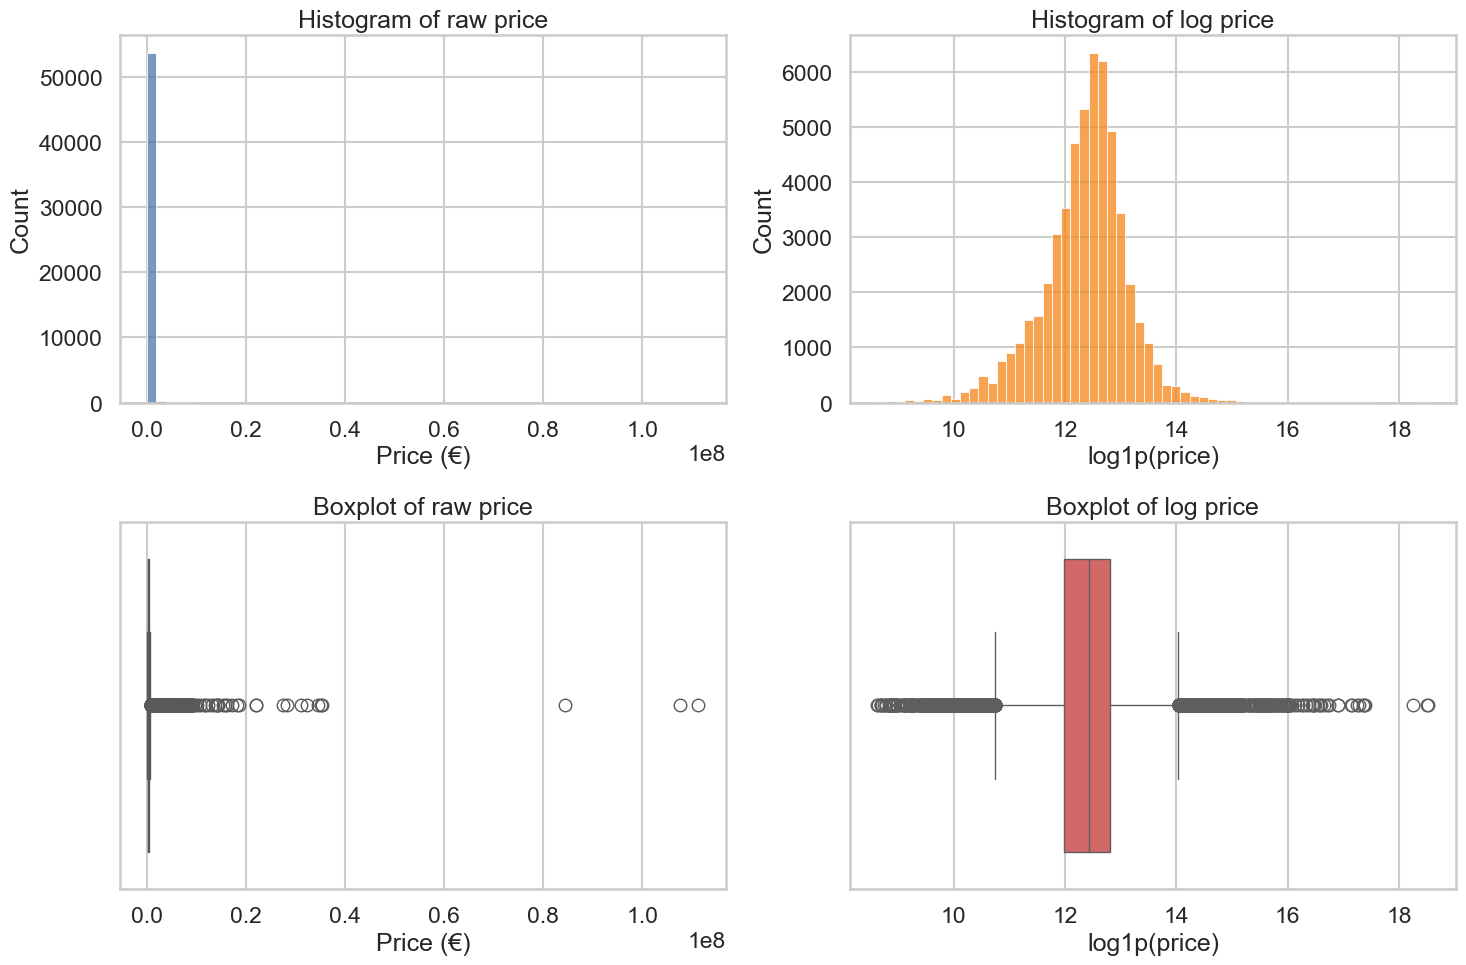

Top 20 highest prices


,sale_date,county_clean,area_code_clean,address_text,price_numeric,log_price
36848,2022-09-01,Dublin,Unknown,DAVITT PRS DEVELOPMENT DAVITT RD DRIMNAGH,"111,280,172.0000",18.5276
31926,2021-12-01,Dublin,Unknown,ST CLARES PARK HAROLDS CROSS RD,"107,488,987.0000",18.4929
23067,2019-06-01,Dublin,D02,6 HANOVER QUAY DUBLIN 2,"84,420,800.0000",18.2513
42596,2023-11-01,Dublin,K36,MALAHIDE RD DUBLIN,"35,344,317.0000",17.3806
36614,2022-07-01,Cork,T12,APARTMENT BG 1 MELBOURN POINT BISHOPSTOWN,"35,178,712.0000",17.3760
22050,2019-08-01,Dublin,Unknown,A1 A7 A9 B1 27 C1 40 D1 23 RICHMOND GARDENS RI...,"34,515,141.0000",17.3569
45302,2023-07-01,Dublin,Unknown,DUNDRUM VIEW BALLINTEER RD DUNDRUM,"32,250,000.0000",17.2890
14496,2018-10-01,Dublin,Unknown,28 29 30 31 AND 32 GARDENS LANE 1 2 2 1 2 AND ...,"31,000,000.0000",17.2495
29221,2020-10-01,Dublin,Unknown,BLOCK E2 DUBLIN LANDINGS,"28,193,832.5900",17.1546
47975,2023-08-01,Dublin,Unknown,WILKINSON S BROOK HOLLYSTOWN,"27,519,823.7900",17.1304


Requested percentiles


,price
0.9000,"525,000.0000"
0.9500,"700,000.0000"
0.9900,"1,452,407.1099"
0.9950,"2,167,400.8800"
0.9990,"6,896,229.1780"


Extreme price flags


,count
above_99_5pct,271
is_extreme_price,54


In [32]:
train["log_price"] = np.log1p(train["price_numeric"])

price_percentiles = train["price_numeric"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])
p995 = price_percentiles.loc[0.995]
p999 = price_percentiles.loc[0.999]

train["above_99_5pct"] = (train["price_numeric"] >= p995).astype("int8")
train["is_extreme_price"] = (train["price_numeric"] >= p999).astype("int8")

target_stats = pd.DataFrame(
    {
        "price_numeric": train["price_numeric"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
        "log_price": train["log_price"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
    }
)
display(target_stats)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(train["price_numeric"], bins=60, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Histogram of raw price")
axes[0, 0].set_xlabel("Price (€)")

sns.histplot(train["log_price"], bins=60, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Histogram of log price")
axes[0, 1].set_xlabel("log1p(price)")

sns.boxplot(x=train["price_numeric"], ax=axes[1, 0], color="#72B7B2")
axes[1, 0].set_title("Boxplot of raw price")
axes[1, 0].set_xlabel("Price (€)")

sns.boxplot(x=train["log_price"], ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Boxplot of log price")
axes[1, 1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()

print("Top 20 highest prices")
display(
    train.sort_values("price_numeric", ascending=False)[
        ["sale_date", "county_clean", "area_code_clean", "address_text", "price_numeric", "log_price"]
    ].head(20)
)

print("Requested percentiles")
display(price_percentiles.to_frame("price"))

print("Extreme price flags")
display(
    pd.DataFrame(
        {
            "count": [
                int(train["above_99_5pct"].sum()),
                int(train["is_extreme_price"].sum()),
            ]
        },
        index=["above_99_5pct", "is_extreme_price"],
    )
)

### Outlier Discussion

At this stage the default choice is to **keep all rows** and work with `log_price`, because dropping expensive sales too early can remove real market structure. The two outlier flags above are useful for diagnostics, but they are **target-derived** and therefore should **not** be used as predictors in the final model.

If later validation proves unstable, a separate modelling notebook can compare:

- full-data modelling with `log_price`
- winsorised target variants
- trimmed subsets used only as sensitivity checks

## 3. Date and Time Features

Time structure matters in housing markets because Ireland experienced strong year-to-year market movement over this period. We create calendar features and cyclical month features, then inspect whether yearly trend and within-year seasonality look useful.

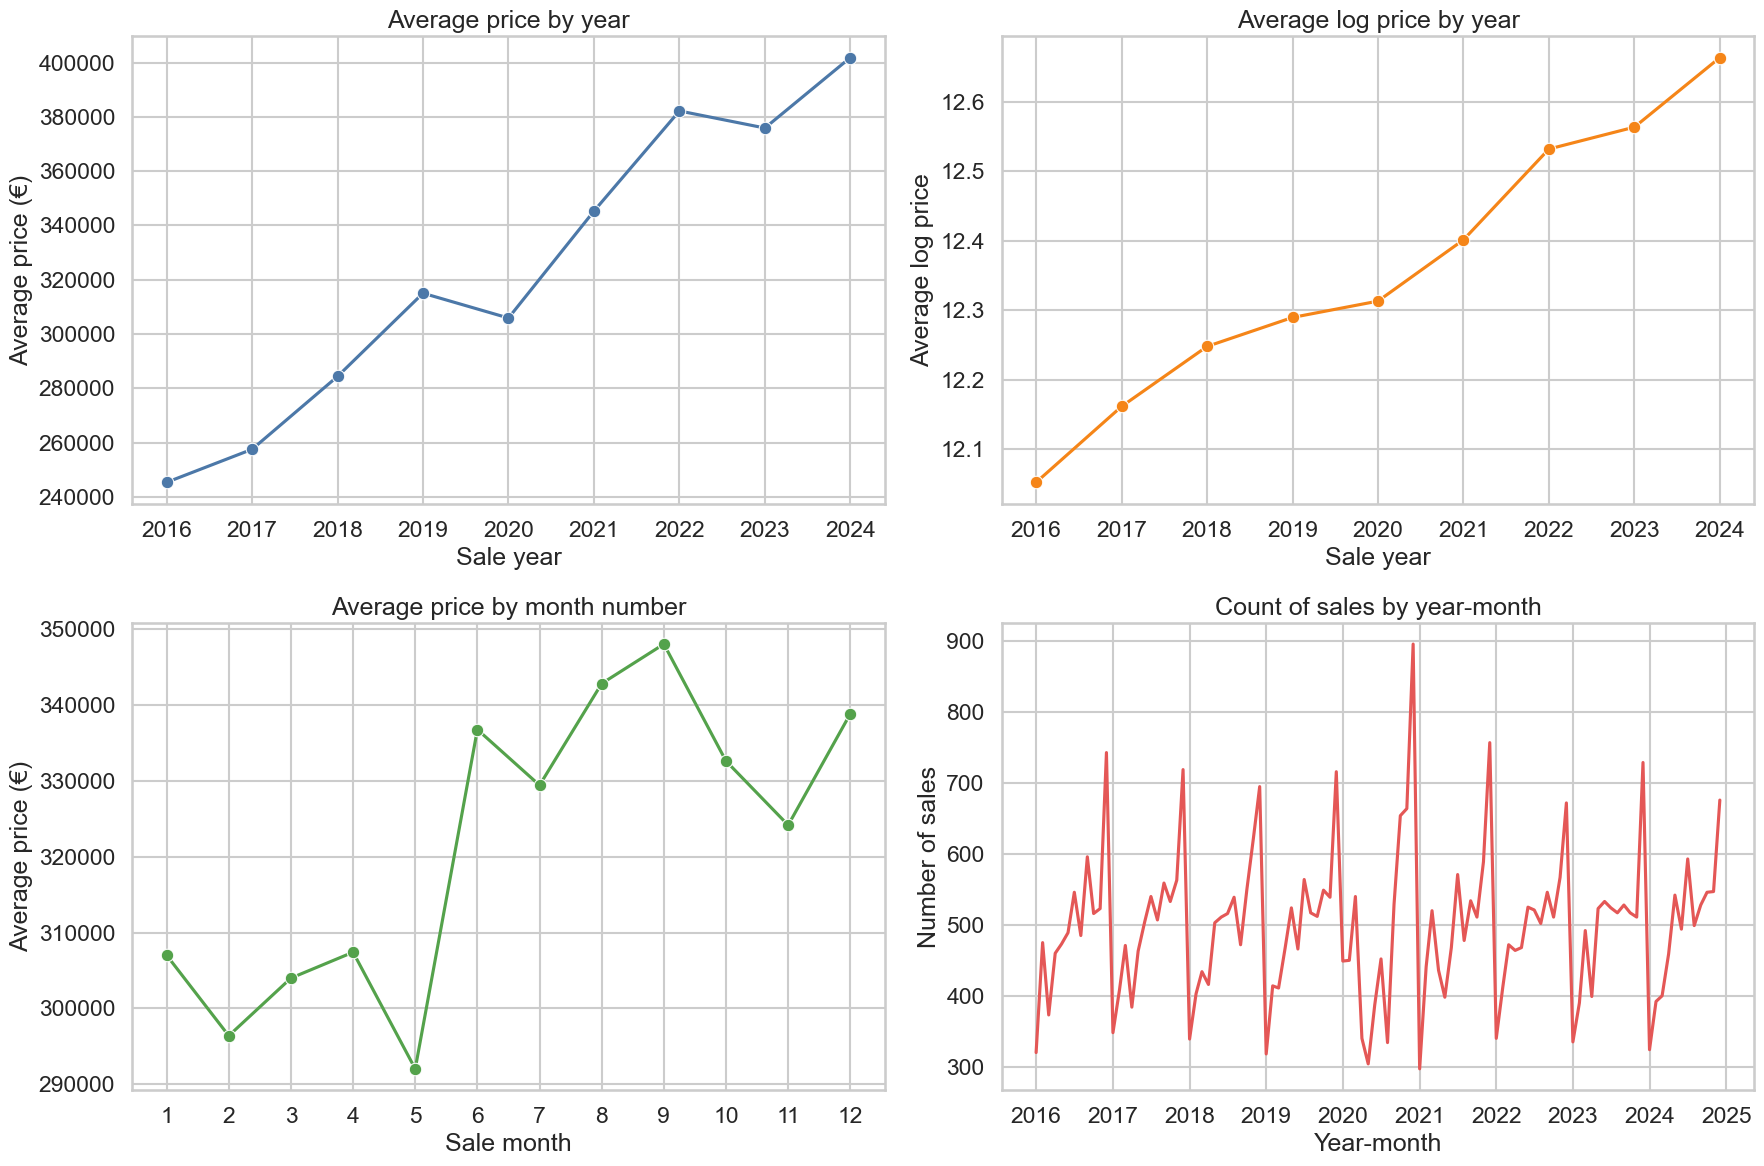

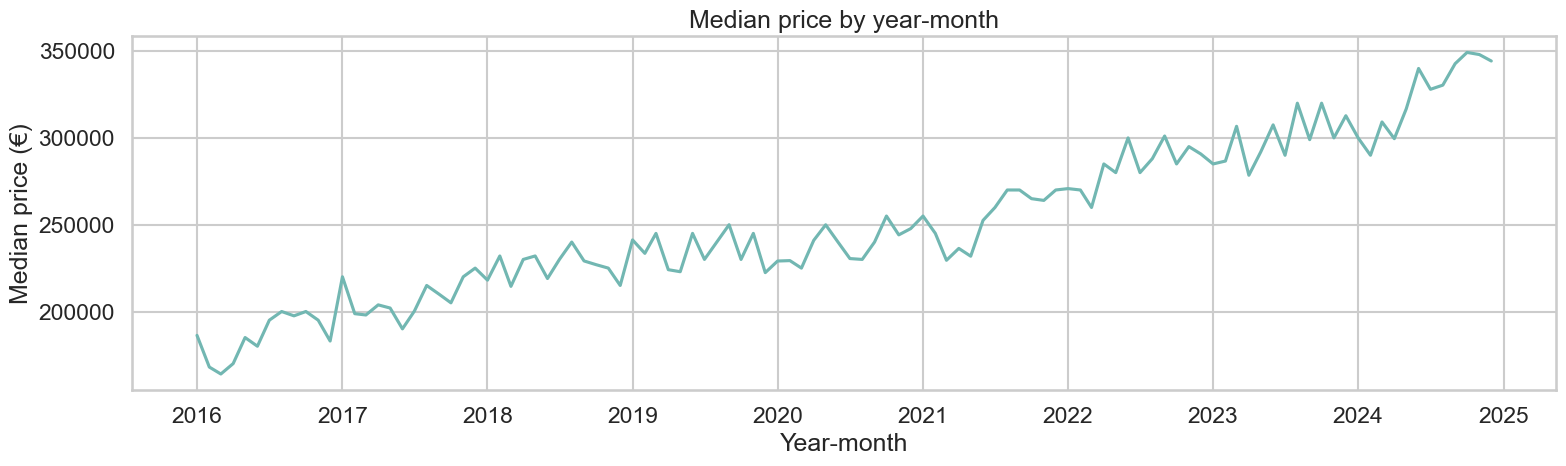

Month-to-month spread in average log price: 0.0970
Start-to-end change in average log price:  0.6110
Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.


In [33]:
yearly_summary = (
    train.groupby("sale_year")
    .agg(avg_price=("price_numeric", "mean"), avg_log_price=("log_price", "mean"))
    .reset_index()
)
month_number_summary = (
    train.groupby("sale_month")
    .agg(avg_price=("price_numeric", "mean"), avg_log_price=("log_price", "mean"))
    .reset_index()
)
period_summary = (
    train.groupby("sale_period")
    .agg(
        sales_count=("price_numeric", "size"),
        median_price=("price_numeric", "median"),
    )
    .reset_index()
)
period_summary["sale_month_start"] = period_summary["sale_period"].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(data=yearly_summary, x="sale_year", y="avg_price", marker="o", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Average price by year")
axes[0, 0].set_xlabel("Sale year")
axes[0, 0].set_ylabel("Average price (€)")

sns.lineplot(data=yearly_summary, x="sale_year", y="avg_log_price", marker="o", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Average log price by year")
axes[0, 1].set_xlabel("Sale year")
axes[0, 1].set_ylabel("Average log price")

sns.lineplot(data=month_number_summary, x="sale_month", y="avg_price", marker="o", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Average price by month number")
axes[1, 0].set_xlabel("Sale month")
axes[1, 0].set_ylabel("Average price (€)")
axes[1, 0].set_xticks(range(1, 13))

sns.lineplot(data=period_summary, x="sale_month_start", y="sales_count", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Count of sales by year-month")
axes[1, 1].set_xlabel("Year-month")
axes[1, 1].set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
sns.lineplot(data=period_summary, x="sale_month_start", y="median_price", color="#72B7B2")
plt.title("Median price by year-month")
plt.xlabel("Year-month")
plt.ylabel("Median price (€)")
plt.tight_layout()
plt.show()

seasonal_spread = month_number_summary["avg_log_price"].max() - month_number_summary["avg_log_price"].min()
yearly_shift = yearly_summary["avg_log_price"].iloc[-1] - yearly_summary["avg_log_price"].iloc[0]

print(f"Month-to-month spread in average log price: {seasonal_spread:.4f}")
print(f"Start-to-end change in average log price:  {yearly_shift:.4f}")

if yearly_shift > seasonal_spread:
    print("Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.")
else:
    print("Interpretation: the seasonal pattern is material enough to justify month and cyclical features alongside the year trend.")

Short interpretation:

The plots above should tell us whether the dominant signal is:

- long-run market trend across years,
- a recurring within-year pattern,
- or both.

In most property settings, `sale_year`, `month_index`, and either `sale_month` or the cyclical pair `sin_month` / `cos_month` are good candidates to carry forward.

## 4. Location Features

Location usually carries the strongest structural signal in housing data. This section standardises county and routing-key information, measures area-code missingness, and checks whether finer-grained location looks useful despite missing values.

Percent missing or unknown in area code: 37.23%
County frequency


,county_clean,count
0,Dublin,16347
1,Cork,5934
2,Kildare,3135
3,Galway,2587
4,Meath,2375
5,Limerick,2011
6,Wexford,1907
7,Wicklow,1843
8,Waterford,1539
9,Louth,1510


Area code frequency


,area_code_clean,count
0,Unknown,20100
1,D15,1112
2,A92,710
3,D24,671
4,W91,642
5,D08,604
6,D04,601
7,A91,599
8,V94,592
9,D07,576


Top 20 area codes by count


,area_code_clean,count
0,Unknown,20100
1,D15,1112
2,A92,710
3,D24,671
4,W91,642
5,D08,604
6,D04,601
7,A91,599
8,V94,592
9,D07,576


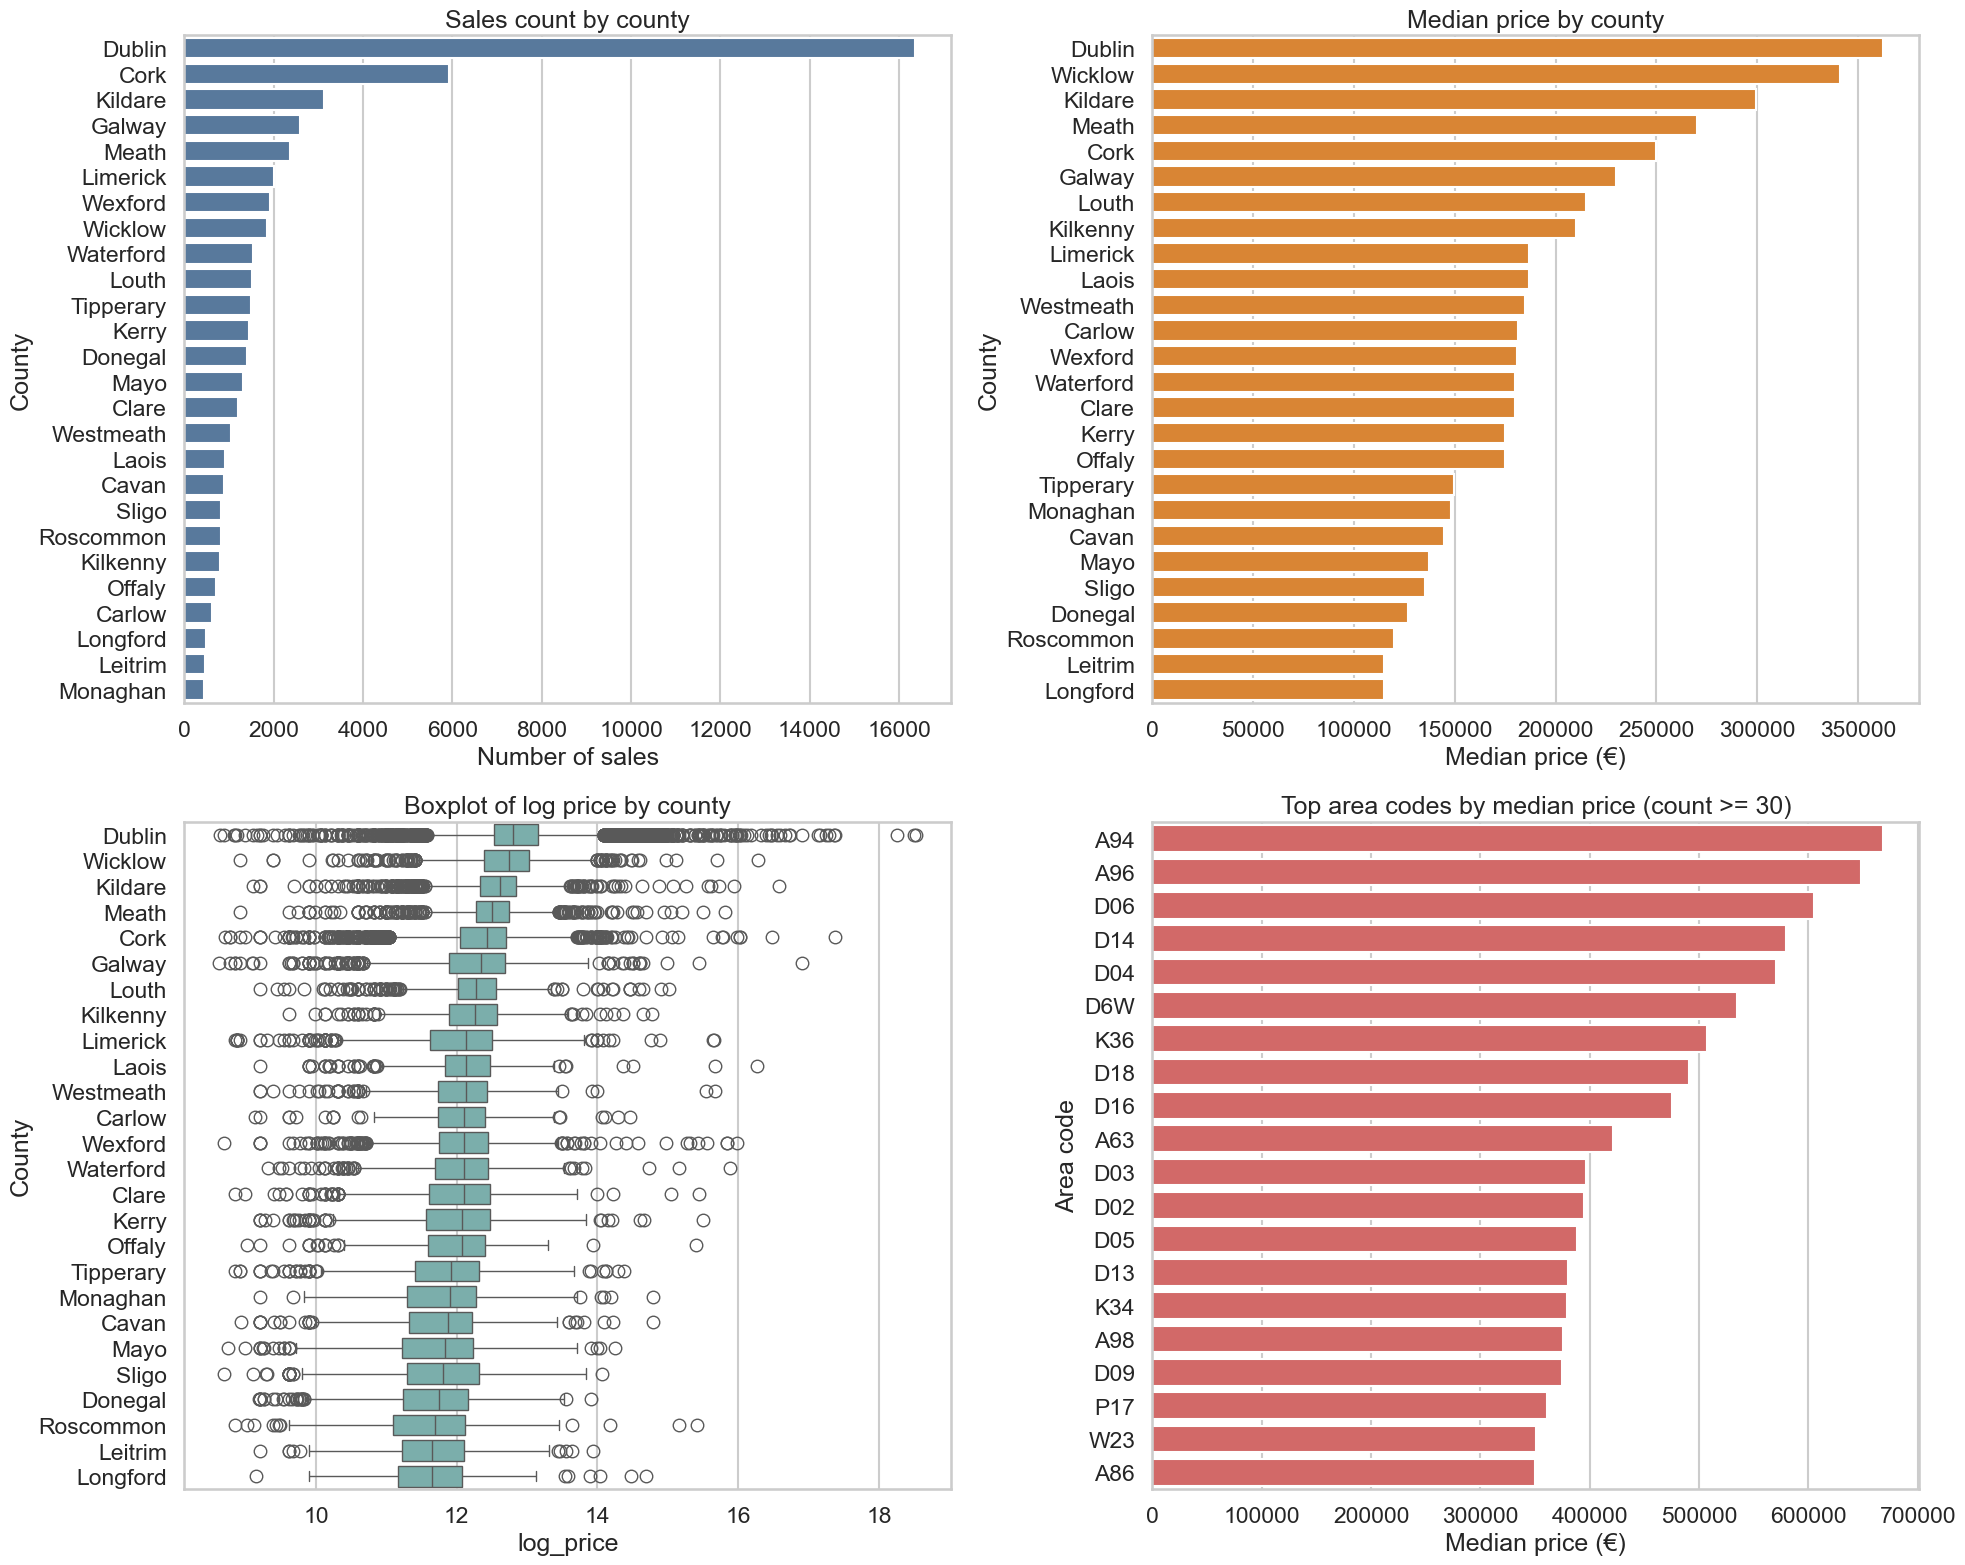

Known vs unknown area-code comparison


,count,mean,median
area_known,,,
Known,33892,12.4430,12.4987
Unknown,20100,12.2151,12.3239


Median log-price gap (Known - Unknown area code): 0.1749


In [34]:
county_freq = train["county_clean"].value_counts(dropna=False).rename_axis("county_clean").reset_index(name="count")
area_freq = train["area_code_clean"].value_counts(dropna=False).rename_axis("area_code_clean").reset_index(name="count")
top_area_counts = area_freq.head(20)
area_missing_pct = train["area_code_missing"].mean() * 100

print(f"Percent missing or unknown in area code: {area_missing_pct:.2f}%")

print("County frequency")
display(county_freq)

print("Area code frequency")
display(area_freq.head(25))

print("Top 20 area codes by count")
display(top_area_counts)

county_median_price = (
    train.groupby("county_clean")
    .agg(median_price=("price_numeric", "median"), count=("price_numeric", "size"))
    .sort_values("median_price", ascending=False)
    .reset_index()
)

area_price_summary = (
    train.loc[train["area_code_missing"] == 0]
    .groupby("area_code_clean")
    .agg(median_price=("price_numeric", "median"), count=("price_numeric", "size"))
    .query("count >= 30")
    .sort_values("median_price", ascending=False)
    .reset_index()
)

known_unknown_compare = (
    train.assign(area_known=np.where(train["area_code_missing"] == 1, "Unknown", "Known"))
    .groupby("area_known")["log_price"]
    .agg(["count", "mean", "median"])
)

county_order = (
    train.groupby("county_clean")["log_price"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.barplot(data=county_freq, y="county_clean", x="count", color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set_title("Sales count by county")
axes[0, 0].set_xlabel("Number of sales")
axes[0, 0].set_ylabel("County")

sns.barplot(data=county_median_price, y="county_clean", x="median_price", color="#F58518", ax=axes[0, 1])
axes[0, 1].set_title("Median price by county")
axes[0, 1].set_xlabel("Median price (€)")
axes[0, 1].set_ylabel("County")

sns.boxplot(
    data=train,
    y="county_clean",
    x="log_price",
    order=county_order,
    ax=axes[1, 0],
    color="#72B7B2",
)
axes[1, 0].set_title("Boxplot of log price by county")
axes[1, 0].set_xlabel("log_price")
axes[1, 0].set_ylabel("County")

sns.barplot(
    data=area_price_summary.head(20),
    y="area_code_clean",
    x="median_price",
    color="#E45756",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Top area codes by median price (count >= 30)")
axes[1, 1].set_xlabel("Median price (€)")
axes[1, 1].set_ylabel("Area code")

plt.tight_layout()
plt.show()

print("Known vs unknown area-code comparison")
display(known_unknown_compare)

median_gap = (
    known_unknown_compare.loc["Known", "median"] - known_unknown_compare.loc["Unknown", "median"]
    if {"Known", "Unknown"}.issubset(known_unknown_compare.index)
    else np.nan
)
print(f"Median log-price gap (Known - Unknown area code): {median_gap:.4f}")

Short conclusion:

If the county plots show clear price separation, county should remain in every baseline model. If the routing-key analysis shows additional separation even after missingness, then `area_code_clean` and `area_code_missing` are worth keeping as a stronger location block.

## 5. Transaction-Type Features

Some transactions differ systematically from standard second-hand full-market sales. These flags may capture sale conditions rather than location, so they are useful to inspect separately.


Not Full Market Price


,count
Not Full Market Price,
No,51182
Yes,2810


,count,avg_price,median_price
Not Full Market Price,,,
No,51182,"330,323.2640","257,000.0000"
Yes,2810,"203,267.7994","162,995.7950"


,avg_log_price,median_log_price
Not Full Market Price,,
No,12.3855,12.4568
Yes,11.8596,12.0015


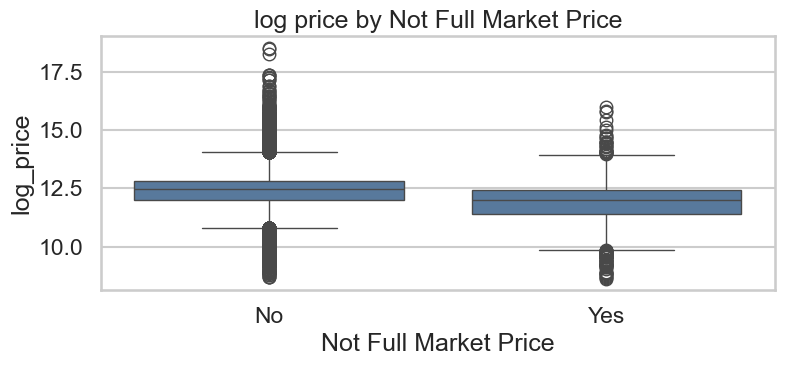

,count
not_full_market_bin,
0.0000,51182
1.0000,2810



VAT Exclusive


,count
VAT Exclusive,
No,44537
Yes,9455


,count,avg_price,median_price
VAT Exclusive,,,
No,44537,"303,068.0434","235,000.0000"
Yes,9455,"420,946.2046","308,400.0000"


,avg_log_price,median_log_price
VAT Exclusive,,
No,12.2999,12.3673
Yes,12.6324,12.6392


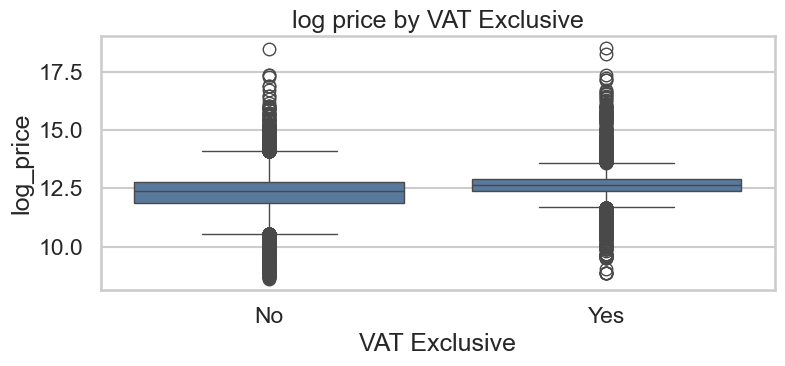

,count
vat_exclusive_bin,
0.0000,44537
1.0000,9455



Is_Second_Hand


,count
Is_Second_Hand,
Yes,44404
No,9588


,count,avg_price,median_price
Is_Second_Hand,,,
No,9588,"419,008.3467","308,370.0500"
Yes,44404,"303,133.4066","235,000.0000"


,avg_log_price,median_log_price
Is_Second_Hand,,
No,12.6256,12.6391
Yes,12.3004,12.3673


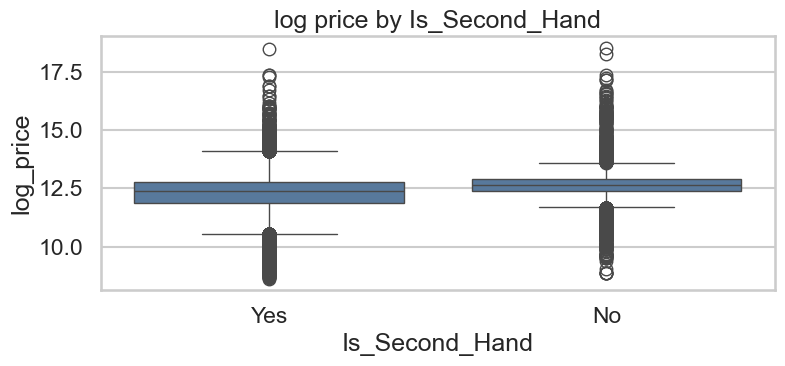

,count
is_second_hand_bin,
1.0000,44404
0.0000,9588



Interaction: Is_Second_Hand x VAT Exclusive


vat_exclusive_bin,0.0000,1.0000,All
is_second_hand_bin,,,
0.0000,133,9455,9588
1.0000,44404,0,44404
All,44537,9455,53992


Interaction: Is_Second_Hand x Not Full Market Price


not_full_market_bin,0.0000,1.0000,All
is_second_hand_bin,,,
0.0000,8982,606,9588
1.0000,42200,2204,44404
All,51182,2810,53992


In [35]:
transaction_specs = [
    ("Not Full Market Price", train_map["not_full_market_col"], "not_full_market_bin"),
    ("VAT Exclusive", train_map["vat_exclusive_col"], "vat_exclusive_bin"),
    ("Is_Second_Hand", train_map["is_second_hand_col"], "is_second_hand_bin"),
]

for label, raw_col, bin_col in transaction_specs:
    print(f"\n{label}")
    if raw_col is not None:
        display(train[raw_col].value_counts(dropna=False).to_frame("count"))
        display(
            train.groupby(raw_col)["price_numeric"]
            .agg(["count", "mean", "median"])
            .rename(columns={"mean": "avg_price", "median": "median_price"})
        )
        display(
            train.groupby(raw_col)["log_price"]
            .agg(["mean", "median"])
            .rename(columns={"mean": "avg_log_price", "median": "median_log_price"})
        )
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=train, x=raw_col, y="log_price", color="#4C78A8")
        plt.title(f"log price by {label}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{label}: raw column not found. Using the clean binary version only if available.")

    if bin_col in train.columns:
        display(train[bin_col].value_counts(dropna=False).rename_axis(bin_col).to_frame("count"))

print("\nInteraction: Is_Second_Hand x VAT Exclusive")
display(
    pd.crosstab(
        train["is_second_hand_bin"],
        train["vat_exclusive_bin"],
        dropna=False,
        margins=True,
    )
)

print("Interaction: Is_Second_Hand x Not Full Market Price")
display(
    pd.crosstab(
        train["is_second_hand_bin"],
        train["not_full_market_bin"],
        dropna=False,
        margins=True,
    )
)

Interpretation:

These transaction flags should be kept if they produce consistent shifts in average or median `log_price`, especially if those shifts persist even after adding location and time controls later in the staged validation section.

## 6. Market Activity Features

Activity features are built from monthly counts and rolling 12-month sales totals. The rolling features are explicitly shifted so that they only use earlier months. The contemporaneous monthly count features are kept for analysis, but they should later be judged carefully for real-time availability.

Summary statistics for market activity features


,count,mean,std,min,25%,50%,75%,max
sales_count_county_month,"53,992.0000",64.6560,66.2260,1.0000,14.0000,27.0000,131.0000,263.0000
sales_count_area_month,"33,892.0000",5.5874,3.9483,1.0000,3.0000,5.0000,7.0000,33.0000
rolling_12m_sales_county,"53,672.0000",690.8941,714.3288,0.0000,153.0000,277.0000,"1,697.0000","1,965.0000"
rolling_12m_sales_area,"33,734.0000",47.6189,34.5928,0.0000,22.0000,41.0000,62.0000,186.0000


Correlation with log_price


,correlation_with_log_price
rolling_12m_sales_county,0.4523
sales_count_county_month,0.4331
rolling_12m_sales_area,0.2337
sales_count_area_month,0.1759


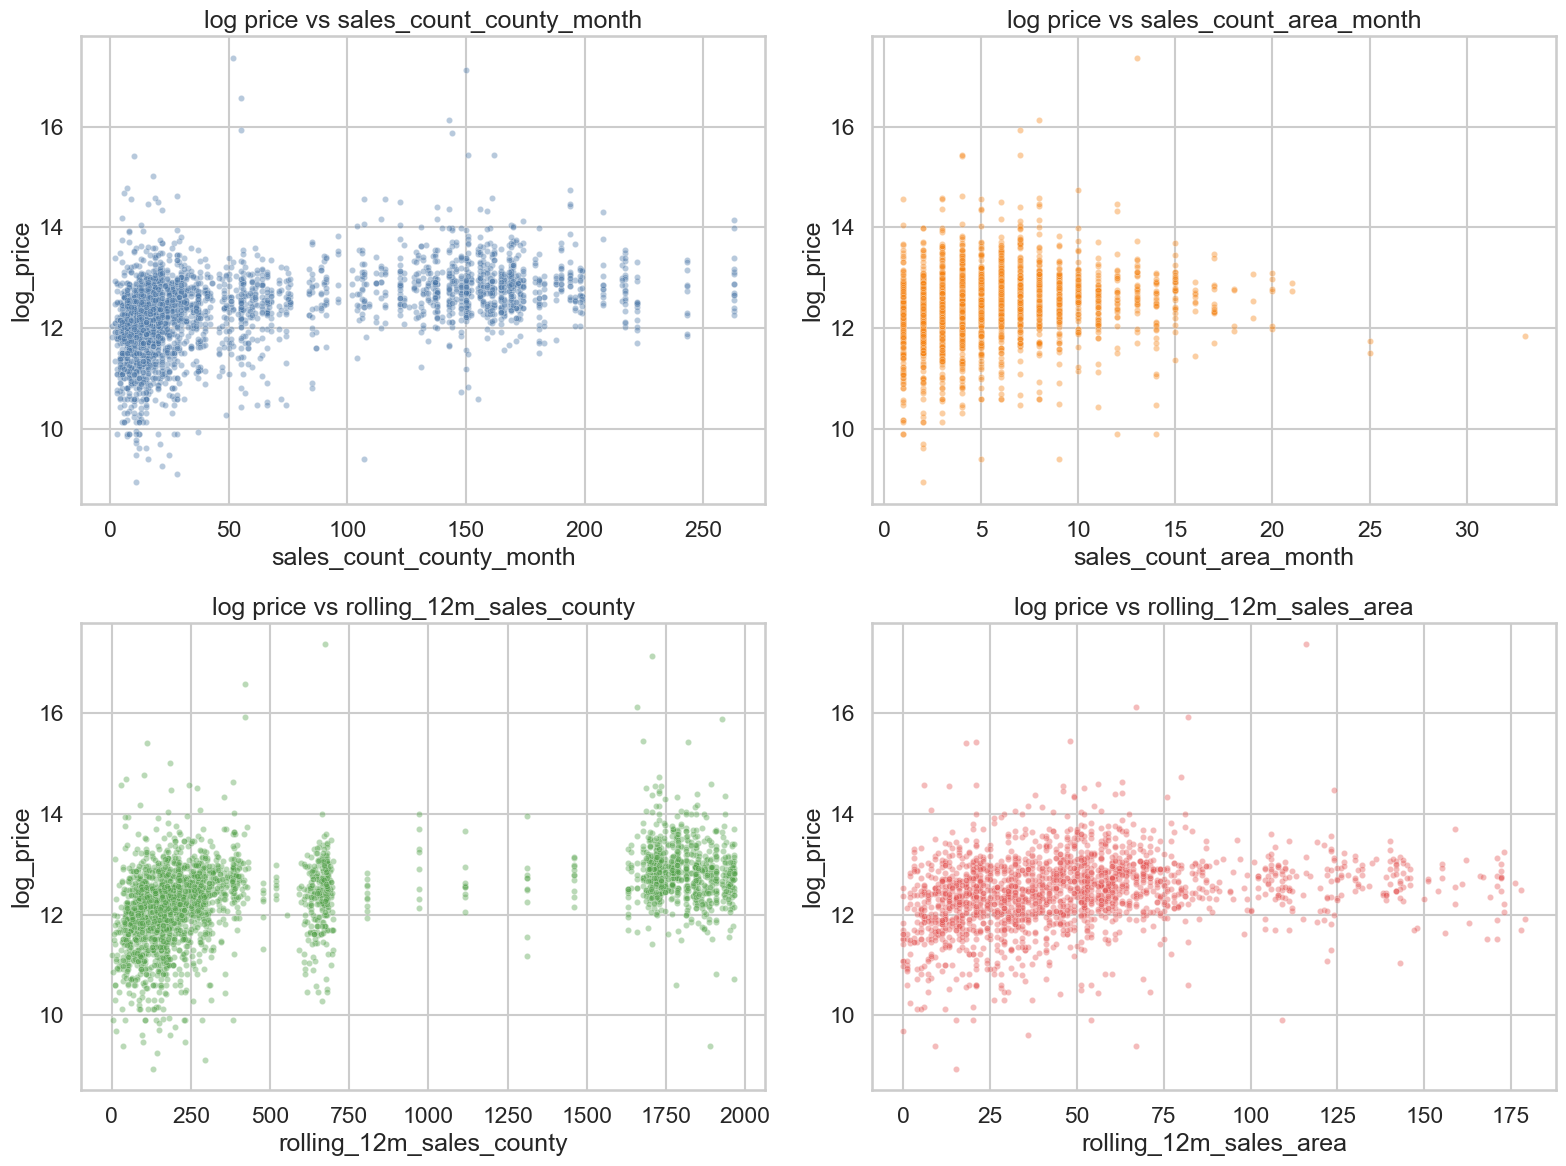

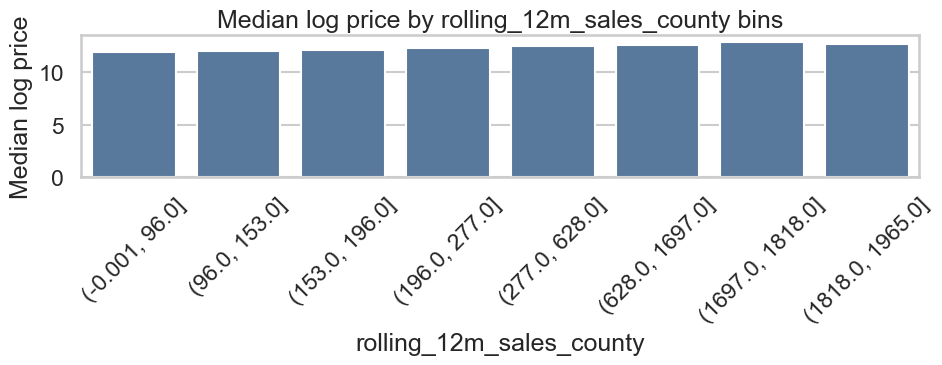

,feature_bin,median,count
0,"(-0.001, 96.0]",11.9117,6916
1,"(96.0, 153.0]",12.0625,6598
2,"(153.0, 196.0]",12.1756,6750
3,"(196.0, 277.0]",12.3673,6637
4,"(277.0, 628.0]",12.5245,6695
5,"(628.0, 1697.0]",12.5726,6802
6,"(1697.0, 1818.0]",12.8866,6645
7,"(1818.0, 1965.0]",12.7367,6629


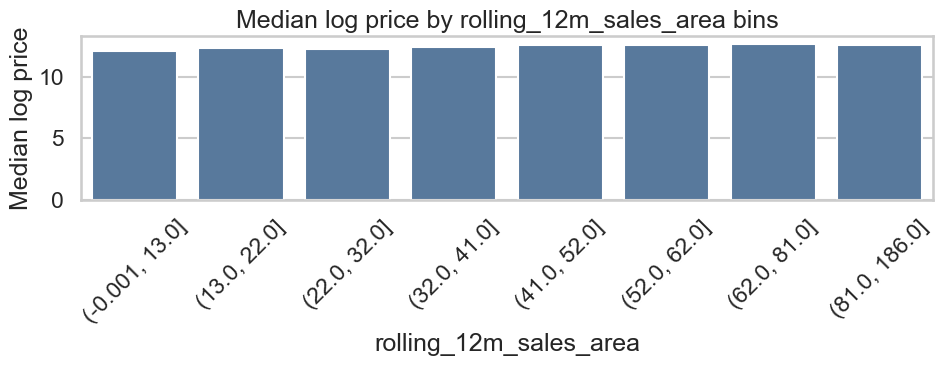

,feature_bin,median,count
0,"(-0.001, 13.0]",12.1281,4635
1,"(13.0, 22.0]",12.3458,3935
2,"(22.0, 32.0]",12.3327,4515
3,"(32.0, 41.0]",12.4684,3842
4,"(41.0, 52.0]",12.6346,4480
5,"(52.0, 62.0]",12.6484,3942
6,"(62.0, 81.0]",12.6916,4264
7,"(81.0, 186.0]",12.6443,4121


Note: for the future 2025 test months, same-month activity counts remain missing because they are not available from training history alone.


In [36]:
max_required_period = max(train["sale_period"].max(), test["sale_period"].max())

train, county_activity_history = add_activity_features(
    train,
    reference_df=train,
    group_col="county_clean",
    prefix="county",
    end_period=max_required_period,
)
train, area_activity_history = add_activity_features(
    train,
    reference_df=train,
    group_col="area_code_clean",
    prefix="area",
    end_period=max_required_period,
)

test, _ = add_activity_features(
    test,
    reference_df=train,
    group_col="county_clean",
    prefix="county",
    end_period=max_required_period,
)
test, _ = add_activity_features(
    test,
    reference_df=train,
    group_col="area_code_clean",
    prefix="area",
    end_period=max_required_period,
)

activity_features = [
    "sales_count_county_month",
    "sales_count_area_month",
    "rolling_12m_sales_county",
    "rolling_12m_sales_area",
]

print("Summary statistics for market activity features")
display(train[activity_features].describe().T)

activity_corr = train[activity_features + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price")
print("Correlation with log_price")
display(activity_corr.sort_values(key=np.abs, ascending=False).to_frame("correlation_with_log_price"))

sampled = train.dropna(subset=["log_price"]).sample(min(3000, len(train)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.scatterplot(
    data=sampled,
    x="sales_count_county_month",
    y="log_price",
    s=20,
    alpha=0.4,
    ax=axes[0, 0],
    color="#4C78A8",
)
axes[0, 0].set_title("log price vs sales_count_county_month")

sns.scatterplot(
    data=sampled,
    x="sales_count_area_month",
    y="log_price",
    s=20,
    alpha=0.4,
    ax=axes[0, 1],
    color="#F58518",
)
axes[0, 1].set_title("log price vs sales_count_area_month")

sns.scatterplot(
    data=sampled,
    x="rolling_12m_sales_county",
    y="log_price",
    s=20,
    alpha=0.4,
    ax=axes[1, 0],
    color="#54A24B",
)
axes[1, 0].set_title("log price vs rolling_12m_sales_county")

sns.scatterplot(
    data=sampled,
    x="rolling_12m_sales_area",
    y="log_price",
    s=20,
    alpha=0.4,
    ax=axes[1, 1],
    color="#E45756",
)
axes[1, 1].set_title("log price vs rolling_12m_sales_area")

plt.tight_layout()
plt.show()

plot_binned_relationship(train, "rolling_12m_sales_county", title="Median log price by rolling_12m_sales_county bins")
plot_binned_relationship(train, "rolling_12m_sales_area", title="Median log price by rolling_12m_sales_area bins")

print(
    "Note: for the future 2025 test months, same-month activity counts remain missing because they are not available from training history alone."
)

## 7. Local Historical Price Features with Leakage Control

This is the most leakage-sensitive block. The feature logic below works only from earlier months by applying `shift(1)` before the rolling median. The same history tables are then used to prepare the separate test set without using any test target values.

Missingness of trailing price features (%)


,pct_missing
county_trailing_6m_median_log_price,2.1900
county_trailing_12m_median_log_price,4.8300
area_trailing_6m_median_log_price,40.9100
area_trailing_12m_median_log_price,42.6000


Correlation with log_price


,correlation_with_log_price
area_trailing_12m_median_log_price,0.6361
area_trailing_6m_median_log_price,0.6246
county_trailing_12m_median_log_price,0.5747
county_trailing_6m_median_log_price,0.5742


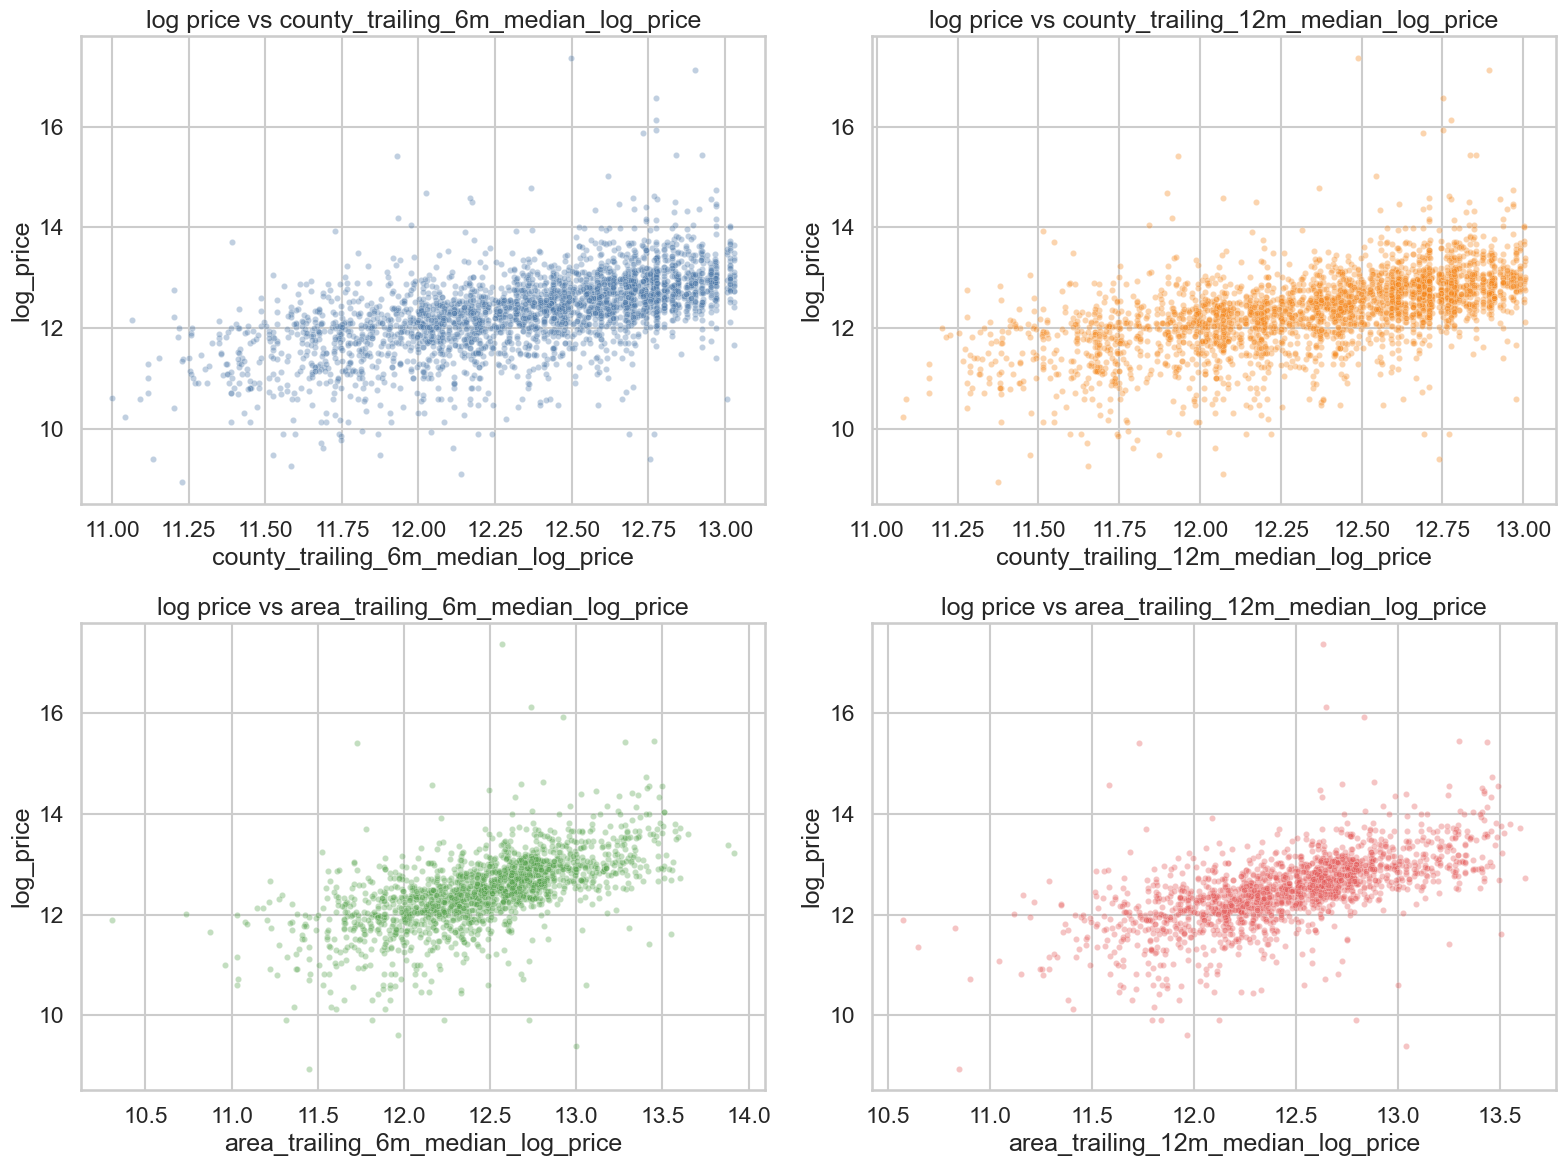

Univariate linear usefulness check for trailing price features


,feature,rmse_log,mae_log,r2,rows_used
3,area_trailing_12m_median_log_price,0.5560,0.3871,0.3122,30994
2,area_trailing_6m_median_log_price,0.5651,0.3946,0.2888,31903
1,county_trailing_12m_median_log_price,0.5884,0.4036,0.2374,51384
0,county_trailing_6m_median_log_price,0.5913,0.4055,0.2297,52811


Strongest trailing feature from this quick check: area_trailing_12m_median_log_price


In [37]:
train, county_price_history = add_trailing_price_features(
    train,
    reference_df=train,
    group_col="county_clean",
    prefix="county",
    end_period=max_required_period,
    windows=(6, 12),
)
train, area_price_history = add_trailing_price_features(
    train,
    reference_df=train,
    group_col="area_code_clean",
    prefix="area",
    end_period=max_required_period,
    windows=(6, 12),
)

test, _ = add_trailing_price_features(
    test,
    reference_df=train,
    group_col="county_clean",
    prefix="county",
    end_period=max_required_period,
    windows=(6, 12),
)
test, _ = add_trailing_price_features(
    test,
    reference_df=train,
    group_col="area_code_clean",
    prefix="area",
    end_period=max_required_period,
    windows=(6, 12),
)

trailing_features = [
    "county_trailing_6m_median_log_price",
    "county_trailing_12m_median_log_price",
    "area_trailing_6m_median_log_price",
    "area_trailing_12m_median_log_price",
]

print("Missingness of trailing price features (%)")
display((train[trailing_features].isna().mean() * 100).round(2).to_frame("pct_missing"))

trailing_corr = train[trailing_features + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price")
print("Correlation with log_price")
display(trailing_corr.sort_values(key=np.abs, ascending=False).to_frame("correlation_with_log_price"))

scatter_sample = train.dropna(subset=["log_price"]).sample(min(3000, len(train)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feature, color in zip(
    axes.flatten(),
    trailing_features,
    ["#4C78A8", "#F58518", "#54A24B", "#E45756"],
):
    sns.scatterplot(
        data=scatter_sample,
        x=feature,
        y="log_price",
        alpha=0.35,
        s=20,
        ax=ax,
        color=color,
    )
    ax.set_title(f"log price vs {feature}")
plt.tight_layout()
plt.show()

univariate_checks = pd.DataFrame(
    [univariate_linear_feature_check(train, feature, target="log_price", val_months=VAL_MONTHS) for feature in trailing_features]
).sort_values("rmse_log")

print("Univariate linear usefulness check for trailing price features")
display(univariate_checks)

strongest_trailing = univariate_checks.iloc[0]["feature"] if not univariate_checks.empty else None
print("Strongest trailing feature from this quick check:", strongest_trailing)

Fallback discussion:

Sparse areas will naturally have more missing trailing-price features than counties. If the area-level version is too sparse, a practical fallback is to retain county-level trailing medians as the safer default and treat area-level history as an optional refinement.

## 8. Optional Address-Based Features

Address-text features are exploratory only. They can sometimes pick up apartment indicators or suburban-estate language, but they may also be noisy and easy to drop later.

/var/folders/f8/6jfxfh0x11x9ffhyn0gglsxr0000gn/T/ipykernel_16397/3326927411.py:109: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_apartment_text"] = address_text.str.contains(
/var/folders/f8/6jfxfh0x11x9ffhyn0gglsxr0000gn/T/ipykernel_16397/3326927411.py:113: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_estate_term"] = address_text.str.contains(
/var/folders/f8/6jfxfh0x11x9ffhyn0gglsxr0000gn/T/ipykernel_16397/3326927411.py:117: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_rural_term"] = address_text.str.contains(
/var/folders/f8/6jfxfh0x11x9ffhyn0gglsxr0000gn/T/ipykernel_16397/3326927411.py:121: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get t

,feature,share_of_rows
0,is_apartment_text,0.0553
1,has_estate_term,0.2669
2,has_rural_term,0.2774
3,has_house_number,0.7910


Address token count summary


,address_token_count
count,"53,992.0000"
mean,5.5188
std,1.4570
min,2.0000
25%,5.0000
50%,6.0000
75%,6.0000
max,22.0000


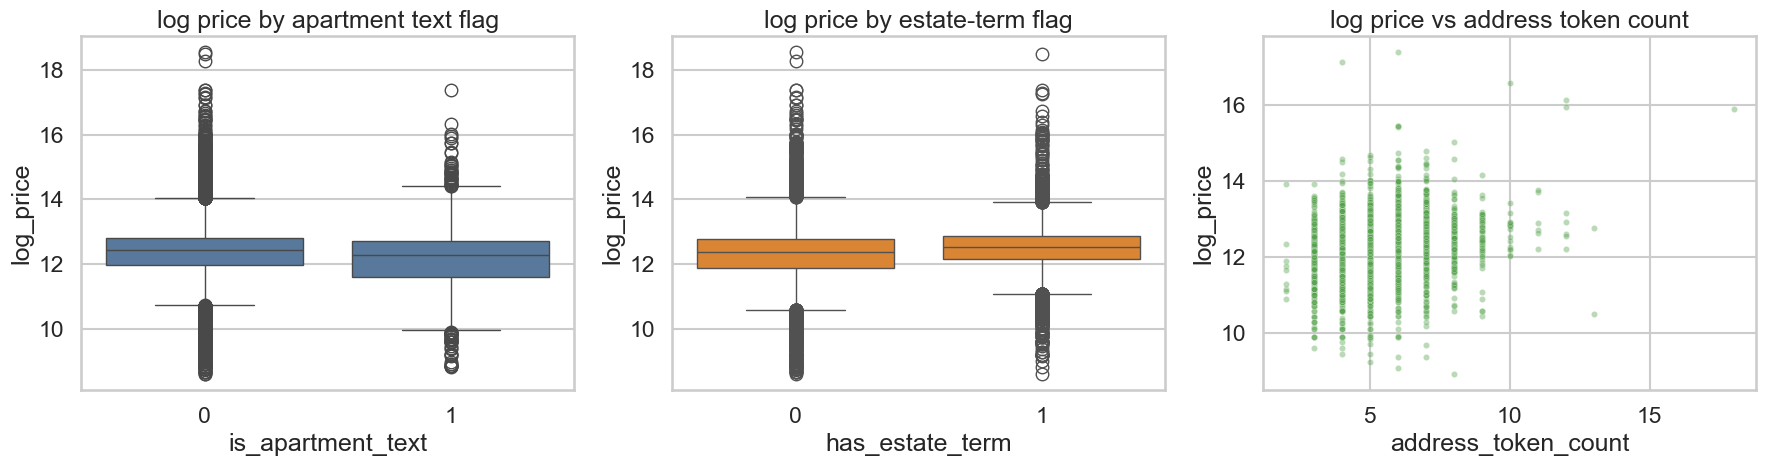

In [38]:
train = add_address_features(train)
test = add_address_features(test)

address_features = [
    "is_apartment_text",
    "has_estate_term",
    "has_rural_term",
    "has_house_number",
    "address_token_count",
]

address_freq = pd.DataFrame(
    {
        "feature": address_features[:-1],
        "share_of_rows": [train[col].mean() for col in address_features[:-1]],
    }
).sort_values("share_of_rows")
display(address_freq)

print("Address token count summary")
display(train["address_token_count"].describe().to_frame("address_token_count"))

sparse_flags = address_freq.query("share_of_rows < 0.02 or share_of_rows > 0.98")
if not sparse_flags.empty:
    print("Very sparse or very common address flags (likely weak candidates):")
    display(sparse_flags)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=train, x="is_apartment_text", y="log_price", color="#4C78A8", ax=axes[0])
axes[0].set_title("log price by apartment text flag")

sns.boxplot(data=train, x="has_estate_term", y="log_price", color="#F58518", ax=axes[1])
axes[1].set_title("log price by estate-term flag")

sns.scatterplot(
    data=train.sample(min(3000, len(train)), random_state=RANDOM_STATE),
    x="address_token_count",
    y="log_price",
    s=20,
    alpha=0.4,
    color="#54A24B",
    ax=axes[2],
)
axes[2].set_title("log price vs address token count")

plt.tight_layout()
plt.show()

## 9. External CSO Features Placeholder

Future CSO data should be merged only after county and time keys are standardised. The safest pattern is:

- standardise county names in both datasets,
- choose a clear period key such as `sale_year` or `(sale_year, sale_quarter)`,
- merge with `validate="m:1"` so each sale row joins to at most one macro row,
- check post-merge missingness before carrying the feature into modelling.

Recommended future CSO feature ideas:

- disposable income index
- live register / labour stress
- housing completions / supply
- planning permissions

In [39]:
def merge_cso_county_year(base_df, cso_df, county_col="county_clean", year_col="sale_year"):
    if cso_df is None or len(cso_df) == 0:
        warnings.warn("No CSO dataframe supplied. Returning the base dataframe unchanged.")
        return base_df.copy()

    required_cols = {county_col, year_col}
    missing = required_cols - set(cso_df.columns)
    if missing:
        raise ValueError(f"CSO dataframe is missing required columns: {sorted(missing)}")

    merge_ready = cso_df.copy()
    merge_ready[county_col] = clean_county_series(merge_ready[county_col])
    merged = base_df.merge(
        merge_ready,
        on=[county_col, year_col],
        how="left",
        validate="m:1",
    )
    return merged


print("Helper ready: merge_cso_county_year(base_df, cso_df, county_col='county_clean', year_col='sale_year')")
print("This section is a placeholder only, so no external files are required for the notebook to run.")

Helper ready: merge_cso_county_year(base_df, cso_df, county_col='county_clean', year_col='sale_year')
This section is a placeholder only, so no external files are required for the notebook to run.


## 10. Feature Usefulness Testing

This section checks whether the engineered features are worth keeping before final modelling. The approach is deliberately lightweight and explainable:

- univariate correlation for numeric features
- univariate mutual information for numeric and categorical features
- a staged Ridge regression comparison using a **time-based validation split**

The staged feature sets are:

- **A. Baseline**: county + sale year + sale month
- **B. Add location refinement + transaction flags**
- **C. Add activity features + trailing price features**
- **D. Add optional address features**

Numeric-feature correlation with log_price


,correlation_with_log_price
area_trailing_12m_median_log_price,0.6361
area_trailing_6m_median_log_price,0.6246
county_trailing_12m_median_log_price,0.5747
county_trailing_6m_median_log_price,0.5742
rolling_12m_sales_county,0.4523
sales_count_county_month,0.4331
month_index,0.2456
sale_year,0.2428
rolling_12m_sales_area,0.2337
address_token_count,0.1780


Univariate mutual information


,feature,mutual_information
17,area_trailing_12m_median_log_price,0.3688
16,area_trailing_6m_median_log_price,0.3545
15,county_trailing_12m_median_log_price,0.3142
14,county_trailing_6m_median_log_price,0.3086
8,vat_exclusive_bin,0.2792
9,is_second_hand_bin,0.2776
24,area_code_clean,0.2700
12,rolling_12m_sales_county,0.2475
23,county_clean,0.2471
10,sales_count_county_month,0.2104


,stage,n_features,rmse_log,mae_log,mae_euro,train_rows,val_rows,val_period_start,val_period_end
3,D. Add optional address,21,0.5477,0.3773,"151,504.9804",47992,6000,2024-01,2024-12
2,C. Add activity + trailing price,16,0.5496,0.3827,"153,667.3725",47992,6000,2024-01,2024-12
1,B. Add area + transaction,8,0.5503,0.3838,"154,280.8654",47992,6000,2024-01,2024-12
0,A. Baseline,3,0.5910,0.4195,"167,384.3122",47992,6000,2024-01,2024-12


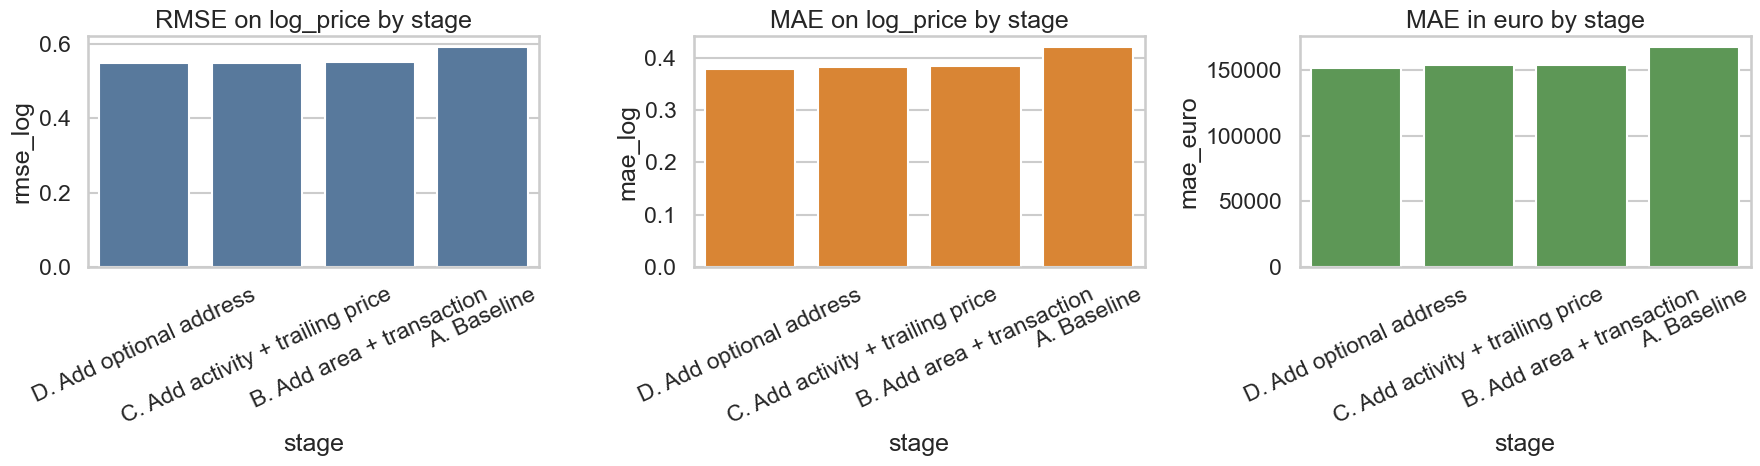

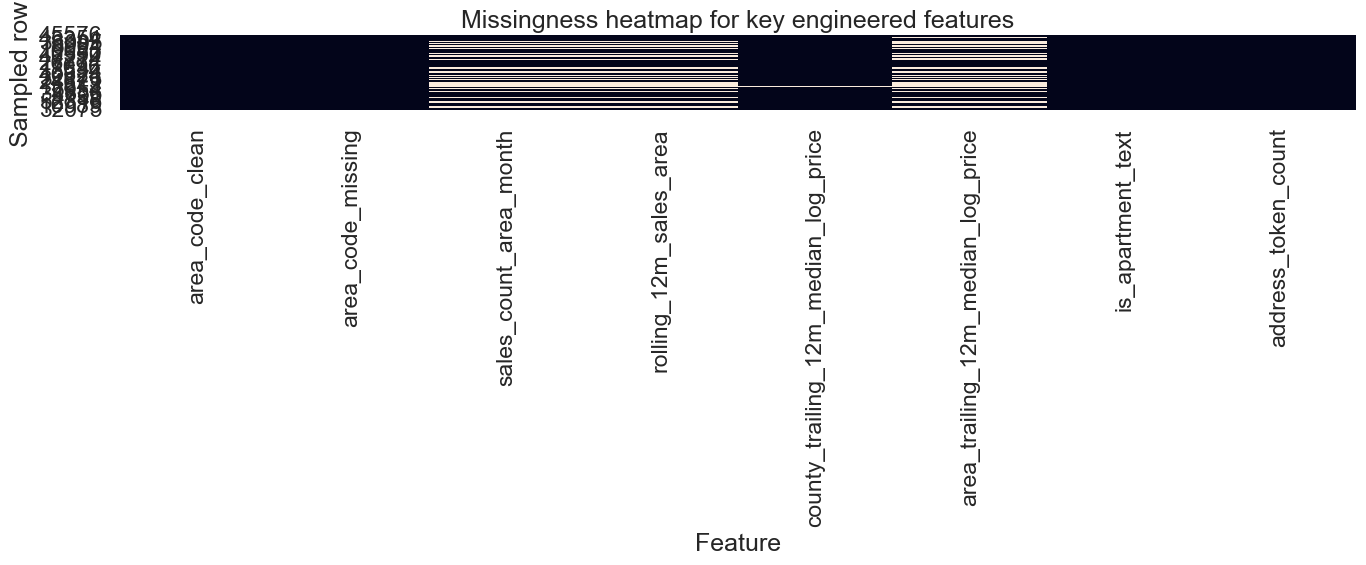

Permutation importance for the best validation stage: D. Add optional address


,feature,importance_mean,importance_std
0,county_clean,0.2667,0.0039
1,area_code_clean,0.0687,0.0021
2,vat_exclusive_bin,0.0342,0.0012
3,not_full_market_bin,0.0226,0.0007
4,is_apartment_text,0.0066,0.0011
5,county_trailing_12m_median_log_price,0.0063,0.0001
6,is_second_hand_bin,0.0045,0.0005
7,sales_count_county_month,0.0041,0.0002
8,has_rural_term,0.0033,0.0005
9,area_trailing_12m_median_log_price,0.0028,0.0001


In [40]:
numeric_candidate_features = [
    "sale_year",
    "sale_month",
    "sale_quarter",
    "month_index",
    "sin_month",
    "cos_month",
    "area_code_missing",
    "not_full_market_bin",
    "vat_exclusive_bin",
    "is_second_hand_bin",
    "sales_count_county_month",
    "sales_count_area_month",
    "rolling_12m_sales_county",
    "rolling_12m_sales_area",
    "county_trailing_6m_median_log_price",
    "county_trailing_12m_median_log_price",
    "area_trailing_6m_median_log_price",
    "area_trailing_12m_median_log_price",
    "is_apartment_text",
    "has_estate_term",
    "has_rural_term",
    "has_house_number",
    "address_token_count",
]
numeric_candidate_features = [col for col in numeric_candidate_features if col in train.columns]

numeric_corr = (
    train[numeric_candidate_features + ["log_price"]]
    .corr(numeric_only=True)["log_price"]
    .drop("log_price")
    .sort_values(key=np.abs, ascending=False)
)
print("Numeric-feature correlation with log_price")
display(numeric_corr.to_frame("correlation_with_log_price"))

mi_features = numeric_candidate_features + ["county_clean", "area_code_clean"]
mi_table = pd.DataFrame(
    {
        "feature": mi_features,
        "mutual_information": [mutual_info_single_feature(train, feature, target="log_price") for feature in mi_features],
    }
).sort_values("mutual_information", ascending=False)
print("Univariate mutual information")
display(mi_table)

stage_specs = {
    "A. Baseline": {
        "numeric": ["sale_year", "sale_month"],
        "categorical": ["county_clean"],
    },
    "B. Add area + transaction": {
        "numeric": ["sale_year", "sale_month", "area_code_missing", "not_full_market_bin", "vat_exclusive_bin", "is_second_hand_bin"],
        "categorical": ["county_clean", "area_code_clean"],
    },
    "C. Add activity + trailing price": {
        "numeric": [
            "sale_year",
            "sale_month",
            "area_code_missing",
            "not_full_market_bin",
            "vat_exclusive_bin",
            "is_second_hand_bin",
            "sales_count_county_month",
            "sales_count_area_month",
            "rolling_12m_sales_county",
            "rolling_12m_sales_area",
            "county_trailing_6m_median_log_price",
            "county_trailing_12m_median_log_price",
            "area_trailing_6m_median_log_price",
            "area_trailing_12m_median_log_price",
        ],
        "categorical": ["county_clean", "area_code_clean"],
    },
    "D. Add optional address": {
        "numeric": [
            "sale_year",
            "sale_month",
            "area_code_missing",
            "not_full_market_bin",
            "vat_exclusive_bin",
            "is_second_hand_bin",
            "sales_count_county_month",
            "sales_count_area_month",
            "rolling_12m_sales_county",
            "rolling_12m_sales_area",
            "county_trailing_6m_median_log_price",
            "county_trailing_12m_median_log_price",
            "area_trailing_6m_median_log_price",
            "area_trailing_12m_median_log_price",
            "is_apartment_text",
            "has_estate_term",
            "has_rural_term",
            "has_house_number",
            "address_token_count",
        ],
        "categorical": ["county_clean", "area_code_clean"],
    },
}

stage_results = []
stage_artefacts = {}

for stage_name, spec in stage_specs.items():
    metrics, artefacts = evaluate_ridge_stage(
        train,
        stage_name=stage_name,
        numeric_features=spec["numeric"],
        categorical_features=spec["categorical"],
        target="log_price",
        val_months=VAL_MONTHS,
    )
    stage_results.append(metrics)
    stage_artefacts[stage_name] = artefacts

stage_results_df = pd.DataFrame(stage_results).sort_values("rmse_log")
display(stage_results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=stage_results_df, x="stage", y="rmse_log", color="#4C78A8", ax=axes[0])
axes[0].set_title("RMSE on log_price by stage")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=stage_results_df, x="stage", y="mae_log", color="#F58518", ax=axes[1])
axes[1].set_title("MAE on log_price by stage")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=stage_results_df, x="stage", y="mae_euro", color="#54A24B", ax=axes[2])
axes[2].set_title("MAE in euro by stage")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

key_missingness_features = [
    "area_code_clean",
    "area_code_missing",
    "sales_count_area_month",
    "rolling_12m_sales_area",
    "county_trailing_12m_median_log_price",
    "area_trailing_12m_median_log_price",
    "is_apartment_text",
    "address_token_count",
]
key_missingness_features = [col for col in key_missingness_features if col in train.columns]

plt.figure(figsize=(14, 6))
heatmap_sample = train[key_missingness_features].sample(min(400, len(train)), random_state=RANDOM_STATE)
sns.heatmap(heatmap_sample.isna(), cbar=False)
plt.title("Missingness heatmap for key engineered features")
plt.xlabel("Feature")
plt.ylabel("Sampled row")
plt.tight_layout()
plt.show()

best_stage_name = stage_results_df.iloc[0]["stage"]
best_artefacts = stage_artefacts[best_stage_name]
best_model = best_artefacts["model"]

perm = permutation_importance(
    best_model,
    best_artefacts["X_val"],
    best_artefacts["y_val"],
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)
permutation_table = (
    pd.DataFrame(
        {
            "feature": best_artefacts["feature_cols"],
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(f"Permutation importance for the best validation stage: {best_stage_name}")
display(permutation_table.head(15))

## 11. Leakage Checks

This section explicitly checks the main leakage risks:

- rolling features should use past data only,
- no target-derived feature should enter the staged models,
- the separate test file should not be used to build target-based history tables,
- risky features should be flagged clearly.

In [41]:
leakage_messages = []

for group_col, feature in [
    ("county_clean", "county_trailing_6m_median_log_price"),
    ("county_clean", "county_trailing_12m_median_log_price"),
    ("area_code_clean", "area_trailing_6m_median_log_price"),
    ("area_code_clean", "area_trailing_12m_median_log_price"),
]:
    if feature in train.columns:
        first_rows = (
            train.loc[train[group_col].notna()]
            .sort_values([group_col, "sale_period"])
            .groupby(group_col, as_index=False)
            .head(1)
        )
        non_na_first_rows = int(first_rows[feature].notna().sum())
        if non_na_first_rows > 0:
            leakage_messages.append(
                f"WARNING: {feature} has {non_na_first_rows} non-null values in the first observed month of a group."
            )

target_derived_features = {"above_99_5pct", "is_extreme_price", "log_price", "price_numeric"}
used_stage_features = {
    feature
    for spec in stage_specs.values()
    for feature in spec["numeric"] + spec["categorical"]
}
overlap = sorted(target_derived_features & used_stage_features)
if overlap:
    leakage_messages.append(f"WARNING: target-derived features entered the staged models: {overlap}")

if test["sales_count_county_month"].notna().sum() > 0 or test["sales_count_area_month"].notna().sum() > 0:
    leakage_messages.append(
        "WARNING: same-month activity counts are populated in the future test set. Review whether those values are genuinely available at scoring time."
    )
else:
    leakage_messages.append(
        "PASS: same-month activity counts for the future test months were left missing because they are not available from training history alone."
    )

if test[trailing_features].notna().sum().sum() == 0:
    leakage_messages.append(
        "WARNING: all trailing price history features are missing on test. Review whether the training history extends far enough."
    )
else:
    leakage_messages.append(
        "PASS: test trailing price features were created from training history only, without using test target values."
    )

leakage_messages.append(
    "CAUTION: sales_count_*_month features are not target leakage, but they are contemporaneous month aggregates and may not be available for true real-time scoring."
)

for message in leakage_messages:
    print(message)

PASS: same-month activity counts for the future test months were left missing because they are not available from training history alone.
PASS: test trailing price features were created from training history only, without using test target values.
CAUTION: sales_count_*_month features are not target leakage, but they are contemporaneous month aggregates and may not be available for true real-time scoring.


## 12. Test Set Feature Generation

The separate test set now has the same non-target engineered columns wherever they can be created safely from existing metadata and training history. The next section checks train/test alignment and turns the feature evidence into a practical shortlist.

## 13. Recommended Feature Set for Final Model

The goal here is not to produce a final production model. Instead, the code below combines the earlier evidence into:

- a summary table of engineered features,
- a keep / optional / drop recommendation,
- a shortlist of safe features that are ready for a later modelling notebook.

In [42]:
train_engineered = train.copy()
test_engineered = test.copy()

feature_registry = [
    {"feature_name": "sale_year", "feature_type": "time", "description": "Calendar year of sale", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "sale_month", "feature_type": "time", "description": "Calendar month number", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "sale_quarter", "feature_type": "time", "description": "Calendar quarter", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "month_index", "feature_type": "time", "description": "Months since earliest training month", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "sin_month", "feature_type": "time", "description": "Cyclical month sine component", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "cos_month", "feature_type": "time", "description": "Cyclical month cosine component", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "county_clean", "feature_type": "location", "description": "Cleaned county name", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "area_code_clean", "feature_type": "location", "description": "Cleaned Eircode routing key / area code", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "area_code_missing", "feature_type": "location", "description": "Flag for missing or unknown area code", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "not_full_market_bin", "feature_type": "transaction", "description": "Binary full-market flag", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "vat_exclusive_bin", "feature_type": "transaction", "description": "Binary VAT exclusive flag", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "is_second_hand_bin", "feature_type": "transaction", "description": "Binary second-hand flag", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "sales_count_county_month", "feature_type": "activity", "description": "Same-month sales count within county", "leakage_risk": "Medium availability risk", "default_recommendation": "Optional"},
    {"feature_name": "sales_count_area_month", "feature_type": "activity", "description": "Same-month sales count within area code", "leakage_risk": "Medium availability risk", "default_recommendation": "Optional"},
    {"feature_name": "rolling_12m_sales_county", "feature_type": "activity", "description": "Prior 12-month county sales volume", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "rolling_12m_sales_area", "feature_type": "activity", "description": "Prior 12-month area-code sales volume", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "county_trailing_6m_median_log_price", "feature_type": "history", "description": "Past 6-month county median log price", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "county_trailing_12m_median_log_price", "feature_type": "history", "description": "Past 12-month county median log price", "leakage_risk": "Low", "default_recommendation": "Keep"},
    {"feature_name": "area_trailing_6m_median_log_price", "feature_type": "history", "description": "Past 6-month area median log price", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "area_trailing_12m_median_log_price", "feature_type": "history", "description": "Past 12-month area median log price", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "is_apartment_text", "feature_type": "address", "description": "Apartment wording in address text", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "has_estate_term", "feature_type": "address", "description": "Estate-like wording in address text", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "has_rural_term", "feature_type": "address", "description": "Rural wording in address text", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "has_house_number", "feature_type": "address", "description": "House-number flag from address text", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "address_token_count", "feature_type": "address", "description": "Token count in address string", "leakage_risk": "Low", "default_recommendation": "Optional"},
    {"feature_name": "above_99_5pct", "feature_type": "target_diagnostic", "description": "Flag for very expensive sales", "leakage_risk": "High (target-derived)", "default_recommendation": "Drop"},
    {"feature_name": "is_extreme_price", "feature_type": "target_diagnostic", "description": "Flag for extreme upper-tail sales", "leakage_risk": "High (target-derived)", "default_recommendation": "Drop"},
]

feature_summary = pd.DataFrame(feature_registry)
feature_summary = feature_summary[feature_summary["feature_name"].isin(set(train_engineered.columns) | set(test_engineered.columns))]

abs_corr_lookup = numeric_corr.abs().to_dict()
mi_lookup = mi_table.set_index("feature")["mutual_information"].to_dict()
perm_lookup = permutation_table.set_index("feature")["importance_mean"].to_dict()

feature_summary["abs_corr_with_log_price"] = feature_summary["feature_name"].map(abs_corr_lookup)
feature_summary["mutual_information"] = feature_summary["feature_name"].map(mi_lookup)
feature_summary["permutation_importance"] = feature_summary["feature_name"].map(perm_lookup)

def recommend_feature(row):
    name = row["feature_name"]
    recommendation = row["default_recommendation"]

    if "High (target-derived)" in row["leakage_risk"]:
        return "Drop"

    if name in {"sales_count_county_month", "sales_count_area_month"} and name in test_engineered.columns:
        if test_engineered[name].notna().sum() == 0:
            return "Optional - unavailable for future months"

    mi_value = row["mutual_information"]
    corr_value = row["abs_corr_with_log_price"]
    perm_value = row["permutation_importance"]

    if pd.notna(perm_value) and perm_value > 0:
        return "Keep"
    if pd.notna(mi_value) and mi_value >= 0.02:
        return "Keep"
    if pd.notna(corr_value) and corr_value >= 0.08:
        return "Keep"
    if row["feature_type"] == "address":
        return "Optional"
    return recommendation

feature_summary["keep_drop_recommendation"] = feature_summary.apply(recommend_feature, axis=1)
feature_summary = feature_summary[
    [
        "feature_name",
        "feature_type",
        "description",
        "leakage_risk",
        "abs_corr_with_log_price",
        "mutual_information",
        "permutation_importance",
        "keep_drop_recommendation",
    ]
].sort_values(["keep_drop_recommendation", "feature_type", "feature_name"])

display(feature_summary)

common_engineered_features = sorted(
    (set(feature_summary["feature_name"]) & set(train_engineered.columns)) & set(test_engineered.columns)
)
train_only_engineered = sorted((set(feature_summary["feature_name"]) & set(train_engineered.columns)) - set(test_engineered.columns))
test_only_engineered = sorted((set(feature_summary["feature_name"]) & set(test_engineered.columns)) - set(train_engineered.columns))

print("Engineered columns present in train but missing in test:")
print(train_only_engineered)

print("Engineered columns present in test but missing in train:")
print(test_only_engineered)

safe_features_ready = feature_summary.loc[
    feature_summary["keep_drop_recommendation"].str.contains("Keep", case=False, na=False)
    & ~feature_summary["leakage_risk"].str.contains("High", na=False)
    & feature_summary["feature_name"].isin(common_engineered_features),
    "feature_name",
].tolist()

optional_features = feature_summary.loc[
    feature_summary["keep_drop_recommendation"].str.contains("Optional", case=False, na=False)
    & feature_summary["feature_name"].isin(common_engineered_features + train_only_engineered),
    "feature_name",
].tolist()

drop_features = feature_summary.loc[
    feature_summary["keep_drop_recommendation"].str.contains("Drop", case=False, na=False)
    | feature_summary["leakage_risk"].str.contains("High", na=False),
    "feature_name",
].tolist()

print("\nSafe features ready for modelling")
print(safe_features_ready)

print("\nOptional features")
print(optional_features)

print("\nFeatures to drop")
print(drop_features)

evidence_table = feature_summary.copy()
for col in ["abs_corr_with_log_price", "mutual_information", "permutation_importance"]:
    max_value = evidence_table[col].fillna(0).max()
    scaled_col = f"{col}_scaled"
    evidence_table[scaled_col] = evidence_table[col].fillna(0) / max_value if max_value and max_value > 0 else 0

evidence_table["evidence_score"] = (
    0.40 * evidence_table["abs_corr_with_log_price_scaled"]
    + 0.35 * evidence_table["mutual_information_scaled"]
    + 0.25 * evidence_table["permutation_importance_scaled"]
)
evidence_table = evidence_table.sort_values("evidence_score", ascending=False)

print("\nStrongest features ranked by notebook evidence")
display(
    evidence_table[
        ["feature_name", "feature_type", "evidence_score", "keep_drop_recommendation"]
    ].head(15)
)

strong_keep_features = evidence_table.loc[
    evidence_table["keep_drop_recommendation"].str.contains("Keep", case=False, na=False)
    & ~evidence_table["leakage_risk"].str.contains("High", na=False),
    "feature_name",
].head(12).tolist()
likely_weak_features = evidence_table.loc[
    evidence_table["keep_drop_recommendation"].str.contains("Optional|Drop", case=False, na=False),
    "feature_name",
].tail(8).tolist()

print("\nRecommended Feature Set for Final Model")
print("Most promising core features:", strong_keep_features)
print("Likely low-value / removable features:", likely_weak_features)

print("\nFinal engineered dataframe shapes")
print("train_engineered:", train_engineered.shape)
print("test_engineered :", test_engineered.shape)

,feature_name,feature_type,description,leakage_risk,abs_corr_with_log_price,mutual_information,permutation_importance,keep_drop_recommendation
25,above_99_5pct,target_diagnostic,Flag for very expensive sales,High (target-derived),NaN,NaN,NaN,Drop
26,is_extreme_price,target_diagnostic,Flag for extreme upper-tail sales,High (target-derived),NaN,NaN,NaN,Drop
15,rolling_12m_sales_area,activity,Prior 12-month area-code sales volume,Low,0.2337,0.1004,-0.0003,Keep
14,rolling_12m_sales_county,activity,Prior 12-month county sales volume,Low,0.4523,0.2475,0.0005,Keep
24,address_token_count,address,Token count in address string,Low,0.1780,0.0517,0.0014,Keep
21,has_estate_term,address,Estate-like wording in address text,Low,0.1088,0.0183,0.0001,Keep
23,has_house_number,address,House-number flag from address text,Low,0.1691,0.0528,0.0021,Keep
22,has_rural_term,address,Rural wording in address text,Low,0.1318,0.0156,0.0033,Keep
20,is_apartment_text,address,Apartment wording in address text,Low,0.0604,0.0175,0.0066,Keep
19,area_trailing_12m_median_log_price,history,Past 12-month area median log price,Low,0.6361,0.3688,0.0028,Keep


Engineered columns present in train but missing in test:
['above_99_5pct', 'is_extreme_price']
Engineered columns present in test but missing in train:
[]

Safe features ready for modelling
['rolling_12m_sales_area', 'rolling_12m_sales_county', 'address_token_count', 'has_estate_term', 'has_house_number', 'has_rural_term', 'is_apartment_text', 'area_trailing_12m_median_log_price', 'area_trailing_6m_median_log_price', 'county_trailing_12m_median_log_price', 'county_trailing_6m_median_log_price', 'area_code_clean', 'area_code_missing', 'county_clean', 'month_index', 'sale_month', 'sale_year', 'is_second_hand_bin', 'not_full_market_bin', 'vat_exclusive_bin']

Optional features
['cos_month', 'sale_quarter', 'sin_month', 'sales_count_area_month', 'sales_count_county_month']

Features to drop
['above_99_5pct', 'is_extreme_price']

Strongest features ranked by notebook evidence


,feature_name,feature_type,evidence_score,keep_drop_recommendation
19,area_trailing_12m_median_log_price,history,0.7526,Keep
18,area_trailing_6m_median_log_price,history,0.7274,Keep
17,county_trailing_12m_median_log_price,history,0.6655,Keep
16,county_trailing_6m_median_log_price,history,0.6515,Keep
14,rolling_12m_sales_county,activity,0.5198,Keep
6,county_clean,location,0.4845,Keep
12,sales_count_county_month,activity,0.4759,Optional - unavailable for future months
10,vat_exclusive_bin,transaction,0.4005,Keep
11,is_second_hand_bin,transaction,0.3695,Keep
7,area_code_clean,location,0.3207,Keep



Recommended Feature Set for Final Model
Most promising core features: ['area_trailing_12m_median_log_price', 'area_trailing_6m_median_log_price', 'county_trailing_12m_median_log_price', 'county_trailing_6m_median_log_price', 'rolling_12m_sales_county', 'county_clean', 'vat_exclusive_bin', 'is_second_hand_bin', 'area_code_clean', 'rolling_12m_sales_area', 'month_index', 'sale_year']
Likely low-value / removable features: ['sales_count_county_month', 'sales_count_area_month', 'sin_month', 'sale_quarter', 'cos_month', 'is_extreme_price', 'above_99_5pct']

Final engineered dataframe shapes
train_engineered: (53992, 43)
test_engineered : (10000, 40)


## Optional Outputs

The cells below are optional and disabled by default. They are included only as convenience tools:

- optional CSV export of engineered train/test copies
- optional pairplot for a small sample of strong numeric features
- optional CatBoost comparison if the library is available locally

In [43]:
WRITE_OPTIONAL_EXPORTS = False
RUN_OPTIONAL_PAIRPLOT = False
RUN_OPTIONAL_CATBOOST = False

if WRITE_OPTIONAL_EXPORTS:
    export_dir = PROJECT_ROOT / "optional_engineered_outputs"
    export_dir.mkdir(exist_ok=True)
    train_engineered.to_csv(export_dir / "ppr_train_engineered.csv", index=False)
    test_engineered.to_csv(export_dir / "ppr_test_engineered.csv", index=False)
    print("Optional engineered CSVs written to:", export_dir)
else:
    print("Optional CSV export is disabled.")

if RUN_OPTIONAL_PAIRPLOT:
    pairplot_features = [
        feature for feature in evidence_table["feature_name"].tolist()
        if feature in numeric_candidate_features
    ][:3]
    pairplot_frame = train_engineered[pairplot_features + ["log_price"]].dropna()
    pairplot_frame = pairplot_frame.sample(min(800, len(pairplot_frame)), random_state=RANDOM_STATE)
    sns.pairplot(pairplot_frame)
    plt.show()
else:
    print("Optional pairplot is disabled.")

if RUN_OPTIONAL_CATBOOST:
    try:
        from catboost import CatBoostRegressor

        cat_features = ["county_clean", "area_code_clean"]
        num_features = [
            "sale_year",
            "sale_month",
            "area_code_missing",
            "not_full_market_bin",
            "vat_exclusive_bin",
            "is_second_hand_bin",
            "rolling_12m_sales_county",
            "rolling_12m_sales_area",
            "county_trailing_12m_median_log_price",
            "area_trailing_12m_median_log_price",
        ]
        catboost_features = [col for col in cat_features + num_features if col in train_engineered.columns]
        cb_df = train_engineered[catboost_features + ["log_price", "sale_period"]].copy()
        cb_df = cb_df[cb_df["log_price"].notna() & cb_df["sale_period"].notna()]

        train_mask, val_mask, val_periods = make_time_based_split(cb_df, val_months=VAL_MONTHS)
        X_train_cb = cb_df.loc[train_mask, catboost_features].copy()
        X_val_cb = cb_df.loc[val_mask, catboost_features].copy()
        y_train_cb = cb_df.loc[train_mask, "log_price"]
        y_val_cb = cb_df.loc[val_mask, "log_price"]

        for col in cat_features:
            if col in X_train_cb.columns:
                X_train_cb[col] = X_train_cb[col].astype("string").fillna("Missing")
                X_val_cb[col] = X_val_cb[col].astype("string").fillna("Missing")

        cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in cat_features if col in X_train_cb.columns]

        cb_model = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            eval_metric="RMSE",
            iterations=300,
            random_seed=RANDOM_STATE,
            verbose=False,
        )
        cb_model.fit(X_train_cb, y_train_cb, cat_features=cat_feature_indices)
        cb_pred = cb_model.predict(X_val_cb)

        print("Optional CatBoost validation")
        print("Validation months:", val_periods.min(), "to", val_periods.max())
        print("RMSE (log):", mean_squared_error(y_val_cb, cb_pred, squared=False))
        print("MAE  (log):", mean_absolute_error(y_val_cb, cb_pred))
        print("MAE (euro):", mean_absolute_error(np.expm1(y_val_cb), np.expm1(cb_pred)))
    except ImportError:
        print("CatBoost is not installed, so the optional comparison was skipped.")
else:
    print("Optional CatBoost comparison is disabled.")

Optional CSV export is disabled.
Optional pairplot is disabled.
Optional CatBoost comparison is disabled.
